# CIO Assignment - Week 2: From Baselines to Your Own Component[](#CIO-Assignment---Week-2:-From-Baselines-to-Your-Own-Component)

## CT099-3-M - Computational Intelligence and Optimisation[](#CT099-3-M---Computational-Intelligence-and-Optimisation)

**What this notebook is for:**
You have run the baselines. Now you will compare them properly, design your first
real novel component, and run your first comparison experiment.

**Before you start - check these in the VS Code Terminal:**

```
PYTHONPATH=. pytest tests/ -q          # should say 49 passed
ls results/nsga2_small/               # should have run_*.json files
ls results/moead_small/               # same
ls results/pls_small/                 # same
```

If any folder is missing, run the baseline now:

```
python scripts/run.py --config configs/nsga2_baseline.yaml \
    --instance instances/ot_small.json --out results/nsga2_small/ --n-runs 3
```

---

## Setup - run this first[](#Setup---run-this-first)

In [1]:
# VS Code: plots display inline automatically.
# If you see no plots, uncomment the next line:
# %matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json, glob, os, sys, time

# Path setup - finds the cio package
if os.path.exists('cio'):
    sys.path.insert(0, '.')
elif os.path.exists('../cio'):
    sys.path.insert(0, '..')
else:
    print('WARNING: Cannot find the cio package.')
    print('Fix: In VS Code, File -> Open Folder -> select the cio_skeleton folder')

from pymoo.indicators.hv import HV
from pymoo.indicators.igd_plus import IGDPlus
from cio.algorithms import build_nsga2, build_moead
from cio.problem import Instance, OTSchedulingProblem
from cio.problem.decoder import GreedyDecoder, ResourceAwareDecoder
from cio.operators import PMXCrossover, OrderCrossover, SwapMutation
from pymoo.optimize import minimize

TEAL, PURPLE, AMBER, GREEN, RED = '#028090','#6B4FA0','#E8A020','#2D9E6B','#C0392B'

inst    = Instance.from_json('instances/ot_small.json')
problem = OTSchedulingProblem(inst)
"""
problem = OTSchedulingProblem(
    inst,
    decoder=ResourceAwareDecoder(window_size=4)
    )
"""
print(f'Instance: {inst}')
print(f'Surgeries: {inst.n_surgeries},  OTs: {inst.n_ots},  Teams: {inst.n_teams},  Horizon: {inst.horizon_days} days')
print('Setup complete.')


Instance: Instance(name='small', horizon=7, n_surgeries=22, n_ots=2, n_teams=3)
Surgeries: 22,  OTs: 2,  Teams: 3,  Horizon: 7 days
Setup complete.


---

## Part 1 - Review your week-1 baseline results[](#Part-1---Review-your-week-1-baseline-results)

Let us load all three baselines and overlay their Pareto fronts on one chart.
This is the first figure you will include in your paper.

In [63]:
def load_results(folder):
    # Load all run_*.json files from a folder
    # Returns list of F arrays (Pareto fronts)
    files = sorted(glob.glob(os.path.join(folder, 'run_*.json')))
    if not files:
        print(f'No results in {folder}')
        print(f'Run: python scripts/run.py --config configs/X.yaml --instance instances/ot_small.json --out {folder}/ --n-runs 3')
        return []
    fronts = []
    for f in files:
        with open(f) as fp: d = json.load(fp)
        fronts.append(np.array(d['F']))
    return fronts

nsga2_results = load_results('results/nsga2_small')
moead_results = load_results('results/moead_small')
pls_results   = load_results('results/pls_small')

print(f'NSGA-II: {len(nsga2_results)} runs loaded')
print(f'MOEA/D:  {len(moead_results)} runs loaded')
print(f'PLS:     {len(pls_results)} runs loaded')


NSGA-II: 3 runs loaded
MOEA/D:  3 runs loaded
PLS:     3 runs loaded


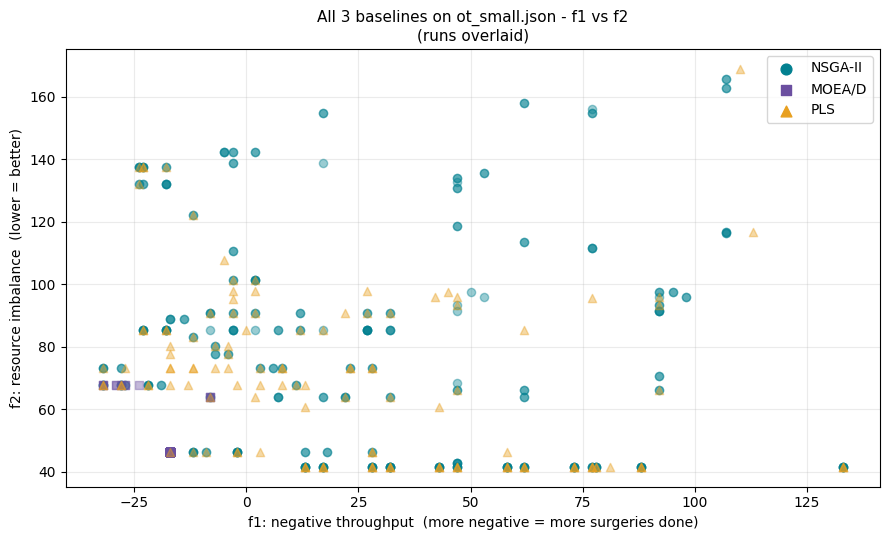

Questions to consider:
  1. Which algorithm covers the widest range of f1 values?
  2. Does one algorithm clearly dominate the others, or do they cover different regions?
  3. Are the 3 runs for each algorithm consistent with each other?


In [64]:
# Overlay all three baselines on one f1 vs f2 chart
missing = [name for name, res in [('NSGA-II', nsga2_results), ('MOEA/D', moead_results), ('PLS', pls_results)] if not res]
if missing:
    print(f'Missing results for: {missing}')
    print('Run the missing baselines in the VS Code Terminal first:')
    for name in missing:
        config = {'NSGA-II':'nsga2','MOEA/D':'moead','PLS':'pls'}[name]
        print(f'  python scripts/run.py --config configs/{config}_baseline.yaml --instance instances/ot_small.json --out results/{config}_small/ --n-runs 3')
else:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    configs = [
        (nsga2_results, TEAL,   'NSGA-II', 'o'),
        (moead_results, PURPLE, 'MOEA/D',  's'),
        (pls_results,   AMBER,  'PLS',     '^'),
    ]
    for fronts, col, label, marker in configs:
        for F in fronts:
            ax.scatter(F[:,0], F[:,1], c=col, s=35, alpha=0.4, marker=marker, zorder=3)
        ax.scatter([], [], c=col, s=60, marker=marker, label=label)

    ax.set_xlabel('f1: negative throughput  (more negative = more surgeries done)', fontsize=10)
    ax.set_ylabel('f2: resource imbalance  (lower = better)', fontsize=10)
    ax.set_title('All 3 baselines on ot_small.json - f1 vs f2\n(runs overlaid)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    print('Questions to consider:')
    print('  1. Which algorithm covers the widest range of f1 values?')
    print('  2. Does one algorithm clearly dominate the others, or do they cover different regions?')
    print('  3. Are the 3 runs for each algorithm consistent with each other?')


---

## Part 2 - Build your results table[](#Part-2---Build-your-results-table)

This table goes directly into your paper. We compute HV, IGD+, and spread
for each algorithm across all runs.

**Important:** we compute a shared reference point from ALL runs combined,
then use the same point for every algorithm.

In [4]:
def build_results_table(results_dict, ref_front_path=None):
    # results_dict: {'Algorithm name': [F_run1, F_run2, ...]}
    # Returns a dict of indicator arrays per algorithm

    # Step 1: shared reference point from all results combined
    all_F = np.vstack([F for fronts in results_dict.values() for F in fronts])
    ref_point = all_F.max(axis=0) * 1.1
    hv_calc   = HV(ref_point=ref_point)
    print(f'Shared reference point: {np.round(ref_point, 1)}')
    print('(This MUST be the same for all algorithms)')
    print()

    # Step 2: load reference front if available
    igd_calc = None
    if ref_front_path and os.path.exists(ref_front_path):
        with open(ref_front_path) as f: ref_data = json.load(f)
        REF_FRONT = np.array(ref_data['points'])
        igd_calc = IGDPlus(REF_FRONT)
        print(f'Reference front loaded: {len(REF_FRONT)} points')
    else:
        print('No reference front file found - IGD+ will be skipped')
        print('To generate: python scripts/generate_reference_fronts.py --instances instances/ --only small')
    print()

    # Step 3: compute indicators
    table = {}
    for name, fronts in results_dict.items():
        hvs     = [float(hv_calc(F)) for F in fronts]
        spreads = [float(np.sum(F.max(axis=0)-F.min(axis=0))) for F in fronts]
        sizes   = [len(F) for F in fronts]
        igds    = [float(igd_calc(F)) for F in fronts] if igd_calc else None
        table[name] = {'hv':hvs, 'spread':spreads, 'size':sizes, 'igd':igds}
    return table, ref_point

# Build the table
results = {
    'NSGA-II': nsga2_results,
    'MOEA/D':  moead_results,
    'PLS':     pls_results,
}
table, ref_point = build_results_table(results, 'instances/ot_small_reference_front.json')


Shared reference point: [146.3 185.9   3.6]
(This MUST be the same for all algorithms)

Reference front loaded: 548 points



In [65]:
# Print the results table
header = f"{'Algorithm':<12}  {'HV mean':>10}  {'HV std':>8}  {'Spread mean':>12}  {'Spread std':>10}  {'Front size':>10}"
print(header)
print('-' * 72)
for name, vals in table.items():
    hv_m  = np.mean(vals['hv'])
    hv_s  = np.std(vals['hv'])
    sp_m  = np.mean(vals['spread'])
    sp_s  = np.std(vals['spread'])
    sz_m  = np.mean(vals['size'])
    row = f'{name:<12}  {hv_m:>10.2f}  {hv_s:>8.2f}  {sp_m:>12.2f}  {sp_s:>10.2f}  {sz_m:>10.1f}'
    print(row)

print()
print('Higher HV = better.   Lower IGD+ = better.   Higher spread = more diverse.')
print('Std shows consistency across runs. High std means unreliable results.')
print()
best_hv = max(table, key=lambda k: np.mean(table[k]['hv']))
print(f'Best HV on this comparison: {best_hv}')


Algorithm        HV mean    HV std   Spread mean  Spread std  Front size
------------------------------------------------------------------------
NSGA-II         85557.58     55.75        279.44       11.63       100.0
MOEA/D          79740.91    750.99         46.71        0.04        22.0
PLS             83404.76   1789.08        274.75       14.87        42.0

Higher HV = better.   Lower IGD+ = better.   Higher spread = more diverse.
Std shows consistency across runs. High std means unreliable results.

Best HV on this comparison: NSGA-II




C:\Users\masri\AppData\Local\Temp\ipykernel_26760\3968002937.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
C:\Users\masri\AppData\Local\Temp\ipykernel_26760\3968002937.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)




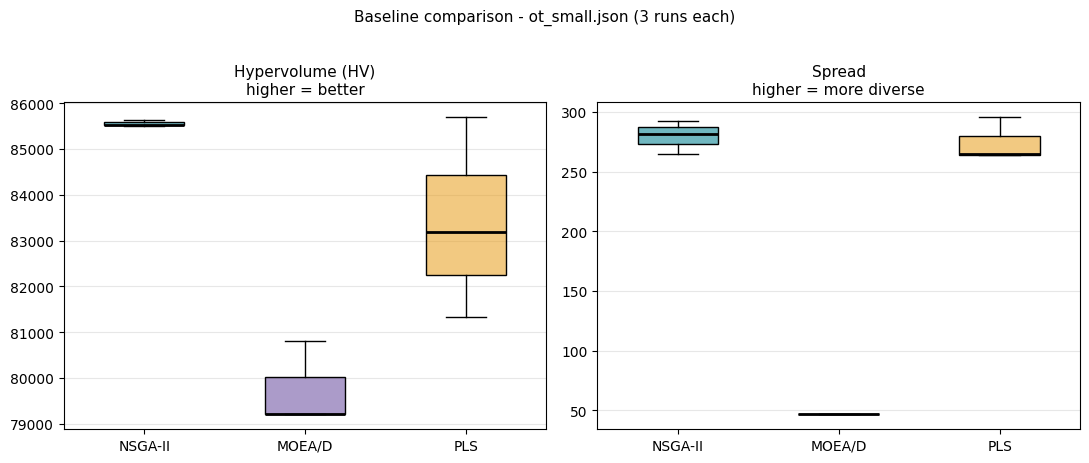

Save this figure - it goes in your paper as Table/Figure 1.


In [ ]:
# Box plots for visual comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, metric, label in [
    (axes[0], 'hv',     'Hypervolume (HV)\nhigher = better'),
    (axes[1], 'spread', 'Spread\nhigher = more diverse'),
]:
    data   = [table[n][metric] for n in table]
    labels = list(table.keys())
    cols   = [TEAL, PURPLE, AMBER]
    bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.5)
    for patch, col in zip(bp['boxes'], cols):
        patch.set_facecolor(col + '90')
    for med in bp['medians']:
        med.set_color('black'); med.set_linewidth(2)
    ax.set_title(label, fontsize=11)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Baseline comparison - ot_small.json (3 runs each)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print('Save this figure - it goes in your paper as Table/Figure 1.')


---

## Part 3 - Write your first real novel component[](#Part-3---Write-your-first-real-novel-component)

**Before you write a line of code:** write your idea in one sentence in the cell below.
If you cannot explain it in one sentence, the idea is not clear enough yet.

**My novel component idea (fill this in before coding):**

Name:

One sentence description:

What hospital knowledge it uses:

Which objective I expect it to improve (f1 / f2 / f3):

In [ ]:
# ── Option A: A priority-preserving crossover ─────────────────────────────
# This is the worked example from the slides.
# Read it, understand it, then modify it to match YOUR idea.

class PriorityPreservingCrossover:
    # Copies all priority-4 and priority-5 surgeries from parent_a
    # into the child, then fills remaining positions from parent_b.
    # Uses hospital knowledge: urgent patients should be scheduled first.

    def __init__(self, instance, priority_threshold=4):
        self.instance  = instance
        self.threshold = priority_threshold

    def __call__(self, parent_a: np.ndarray, parent_b: np.ndarray, rng) -> tuple:
        # Find urgent surgery indices in parent_a's order
        urgent = [
            i for i in parent_a
            if self.instance.surgeries[i].priority >= self.threshold
        ]
        urgent_set = set(urgent)

        # Fill rest from parent_b, skipping already placed
        rest = [i for i in parent_b if i not in urgent_set]
        child1 = np.array(urgent + rest, dtype=int)

        # Child 2: swap roles of parents
        urgent2 = [
            i for i in parent_b
            if self.instance.surgeries[i].priority >= self.threshold
        ]
        rest2 = [i for i in parent_a if i not in set(urgent2)]
        child2 = np.array(urgent2 + rest2, dtype=int)

        return child1, child2


# ── Validity test ─────────────────────────────────────────────────────────
cx = PriorityPreservingCrossover(inst, priority_threshold=4)
rng = np.random.default_rng(0)

errors = 0
for _ in range(50):
    pa = rng.permutation(inst.n_surgeries)
    pb = rng.permutation(inst.n_surgeries)
    c1, c2 = cx(pa, pb, rng)
    if sorted(c1.tolist()) != list(range(inst.n_surgeries)): errors += 1
    if sorted(c2.tolist()) != list(range(inst.n_surgeries)): errors += 1

if errors == 0:
    print('Validity: OK - all children are valid permutations')

    # Count how many urgent surgeries are in the first half
    pa = rng.permutation(inst.n_surgeries)
    pb = rng.permutation(inst.n_surgeries)
    c1, _ = cx(pa, pb, rng)
    half = inst.n_surgeries // 2
    urgent_in_first_half = sum(
        1 for i in c1[:half]
        if inst.surgeries[i].priority >= 4
    )
    urgent_total = sum(1 for s in inst.surgeries if s.priority >= 4)
    print(f'Urgent surgeries in first half of child: {urgent_in_first_half} / {urgent_total}')
    print(f'(In a random permutation, you would expect ~{urgent_total//2})')
else:
    print(f'INVALID: {errors} bad permutations produced - check your logic')


In [ ]:
# ── Option B: Write your OWN component here ───────────────────────────────
# Replace or extend the class above with your design.
# Remember:
#   - For crossover: def __call__(self, parent_a, parent_b, rng) -> tuple
#   - For mutation:  def __call__(self, perm, rng) -> np.ndarray
#   - Always return a COPY (never modify the input array in place)
#   - Always return a valid permutation of 0..n_surgeries-1

class MyNovelComponent:
    # Replace this description:
    # Name: [YOUR NAME]
    # What it does: [ONE SENTENCE]
    # Hospital knowledge used: [WHAT YOU EXPLOIT]

    def __init__(self, instance):
        self.instance = instance

    def __call__(self, parent_a: np.ndarray, parent_b: np.ndarray, rng) -> tuple:
        # YOUR DESIGN HERE
        # For now: passthrough stub - replace with real logic
        return parent_a.copy(), parent_b.copy()


# Validity test for your component
my_cx = MyNovelComponent(inst)
errors = 0
for _ in range(50):
    pa = rng.permutation(inst.n_surgeries)
    pb = rng.permutation(inst.n_surgeries)
    c1, c2 = my_cx(pa, pb, rng)
    if sorted(c1.tolist()) != list(range(inst.n_surgeries)): errors += 1
    if sorted(c2.tolist()) != list(range(inst.n_surgeries)): errors += 1

print(f'Validity: {"OK" if errors == 0 else f"FAIL - {errors} invalid permutations"}')


---

## Part 4 - Run your first comparison experiment[](#Part-4---Run-your-first-comparison-experiment)

Same seeds, same generations, same instance — only the operator changes.
This is what a valid controlled experiment looks like.

In [88]:
# ============================================================
# FINAL 2x2 FACTORIAL EXPERIMENT RUNNER - VALIDATION VERSION
# ============================================================
# --- Part 4: baseline vs graph-guided crossover ----------------
from cio.operators.operators import GraphGuidedPMXCrossover

SEEDS = [0, 1, 2]
N_GEN = 30
POP_SIZE = 50

COMPONENT_NAME = "GraphGuidedPMXCrossover"

baseline_fronts = []
custom_fronts = []

print(f"Running NSGA-II baseline vs {COMPONENT_NAME}")
print(f"Seeds: {SEEDS}, Generations: {N_GEN}, Instance: ot_small")
print()

for seed in SEEDS:

    # --------------------------------------------------
    # Baseline NSGA-II
    # Standard PMX + standard SwapMutation
    # --------------------------------------------------

    baseline_problem = OTSchedulingProblem(
        inst,
        decoder=GreedyDecoder()
    )

    res_base = minimize(
        baseline_problem,
        build_nsga2(
            pop_size=POP_SIZE,
            crossover=PMXCrossover(),
            mutation=SwapMutation(),
            seed=seed
        ),
        ('n_gen', N_GEN),
        seed=seed,
        verbose=False
    )

    baseline_fronts.append(
        res_base.F
    )


    # --------------------------------------------------
    # Our component
    # Graph-guided PMX + SAME standard SwapMutation
    # --------------------------------------------------

    custom_problem = OTSchedulingProblem(
        inst,
        decoder=GreedyDecoder()
    )

    res_custom = minimize(
        custom_problem,
        build_nsga2(
            pop_size=POP_SIZE,
            crossover=GraphGuidedPMXCrossover(
                instance=inst,
                max_window=6
            ),
            mutation=SwapMutation(),
            seed=seed
        ),
        ('n_gen', N_GEN),
        seed=seed,
        verbose=False
    )

    custom_fronts.append(
        res_custom.F
    )


    print(
        f"  seed={seed}: "
        f"baseline={len(res_base.F)} solutions, "
        f"graph-PMX={len(res_custom.F)} solutions"
    )

print()
print("Done.")


Running NSGA-II baseline vs GraphGuidedPMXCrossover
Seeds: [0, 1, 2], Generations: 30, Instance: ot_small

  seed=0: baseline=50 solutions, graph-PMX=50 solutions
  seed=1: baseline=50 solutions, graph-PMX=50 solutions
  seed=2: baseline=50 solutions, graph-PMX=50 solutions

Done.


In [89]:
# --- Compare baseline vs graph-guided crossover ----------------
all_combined = np.vstack(
    baseline_fronts + custom_fronts
)

shared_ref = all_combined.max(axis=0) * 1.1

hv_cmp = HV(
    ref_point=shared_ref
)

hvs_base = [
    hv_cmp(F)
    for F in baseline_fronts
]

hvs_custom = [
    hv_cmp(F)
    for F in custom_fronts
]

print(
    f"{'Metric':<15}"
    f"{'Baseline mean':>15}"
    f"{'Graph PMX mean':>18}"
)

print("-" * 50)

print(
    f"{'HV':<15}"
    f"{np.mean(hvs_base):>15.2f}"
    f"{np.mean(hvs_custom):>18.2f}"
)

hv_change = (
    (
        np.mean(hvs_custom)
        - np.mean(hvs_base)
    )
    / np.mean(hvs_base)
    * 100
)

print()
print(
    f"HV change: "
    f"{hv_change:+.2f}%"
)


Metric           Baseline mean    Graph PMX mean
--------------------------------------------------
HV                    95060.80          94986.30

HV change: -0.08%


---

## Part 5 - Your plan for weeks 3-4[](#Part-5---Your-plan-for-weeks-3-4)

Fill in the table below. Be specific — vague plans do not get done.

**My week 3-4 plan:**

| Task | Target date | Status |
| --- | --- | --- |
| Scale baselines to 10 runs each (ot\_small) | Week 3 | not started |
| Iterate on first novel component based on today's results | Week 3 | not started |
| Design and implement second novel component | Week 3 | not started |
| Run both novel components vs baselines (10 seeds) | Week 3 | not started |
| Run all baselines on ot\_medium (10 runs) | Week 4 | not started |
| Draft Methods section of paper | Week 4 | not started |
| Prepare mid-trimester commitment | Week 4 | not started |

**My second novel component idea (one sentence):**

**What I will do differently based on today's results:**

---

## Quick reference for the next two weeks[](#Quick-reference-for-the-next-two-weeks)

| Task | Command or code |
| --- | --- |
| Scale to 10 runs | `python scripts/run.py ... --n-runs 10` |
| Run on medium instance | `--instance instances/ot_medium.json` |
| Use your operator | `build_nsga2(crossover=MyOp(), seed=0)` |
| Compute HV | `HV(ref_point=shared_ref)(F)` |
| Compute IGD+ | `IGDPlus(ref_front)(F)` |
| Statistical test | `from cio.analysis.statistics import friedman, vargha_delaney` |
| Check validity | `sorted(child.tolist()) == list(range(inst.n_surgeries))` |

**Statistical tests note:** Friedman + Holm requires at least 3 configurations
and ideally 30 runs. For 2-way comparisons (your operator vs baseline),
use Wilcoxon signed-rank + Vargha-Delaney A-measure.

## Designed Component 1 — Graph-Guided Local Search[](#Designed-Component-1-%E2%80%94-Graph-Guided-Local-Search)

Sanity check for the graph-guided local-search operator.
The test verifies that the operator preserves permutation validity
and can refine the objective vector of a candidate schedule.

In [3]:
from cio.problem.evaluator import evaluate as _evaluate
from cio.operators.local_search import GraphGuidedLocalSearch

# Create one random permutation
rng = np.random.default_rng(42)
perm = rng.permutation(inst.n_surgeries)

# Create our graph-guided local search
graph_ls = GraphGuidedLocalSearch(
    neighbourhood_size=4
)

# Run local search
improved_perm, improved_F = graph_ls(
    problem=OTSchedulingProblem(inst),
    perm=perm,
    budget=30,
    rng=rng
)

# Evaluate the original permutation
original_problem = OTSchedulingProblem(inst)
original_schedule = original_problem.decoder(inst, perm)
original_F = np.array(
    _evaluate(inst, original_schedule)
)

print("Original permutation:")
print(perm)

print("\nAfter graph-guided local search:")
print(improved_perm)

print("\nOriginal F:")
print(original_F)

print("\nImproved F:")
print(improved_F)

print("\nPermutation still valid:")
print(
    sorted(improved_perm.tolist())
    == list(range(inst.n_surgeries))
)


Original permutation:
[17 10 16 21 12 15  7  6  9  3  0 18  5 11 14 20  2  4 19  1 13  8]

After graph-guided local search:
[17 10 16 21 12 15  7  6  9  3  0 18 11  5 14 20  2  4 19  1 13  8]

Original F:
[103.     74.25    1.665]

Improved F:
[ 66.     140.       1.0475]

Permutation still valid:
True


In [5]:
for r in results:

    print(
        f"Run {r['run']:2d} | "
        f"f1 {r['original_f1']:6.2f}"
        f" -> {r['graph_f1']:6.2f} | "
        f"f2 {r['original_f2']:7.2f}"
        f" -> {r['graph_f2']:7.2f} | "
        f"f3 {r['original_f3']:6.3f}"
        f" -> {r['graph_f3']:6.3f}"
    )


Run  1 | f1 103.00 ->  66.00 | f2   74.25 ->  140.00 | f3  1.665 ->  1.048
Run  2 | f1 103.00 ->  58.00 | f2  118.50 ->   82.75 | f3  1.710 ->  2.733
Run  3 | f1  55.00 ->  28.00 | f2   95.25 ->   73.25 | f3  1.399 ->  0.349
Run  4 | f1  61.00 ->  29.00 | f2   73.00 ->  130.25 | f3  0.943 ->  0.594
Run  5 | f1  17.00 ->  17.00 | f2   67.75 ->   67.75 | f3  0.508 ->  0.508
Run  6 | f1  69.00 ->  69.00 | f2  149.00 ->   97.50 | f3  2.724 ->  2.459
Run  7 | f1 118.00 -> 119.00 | f2  110.00 ->   41.50 | f3  5.672 ->  2.879
Run  8 | f1 136.00 -> 118.00 | f2  147.00 ->   82.75 | f3  1.383 ->  0.913
Run  9 | f1 128.00 ->  68.00 | f2  152.75 ->  103.50 | f3  1.602 ->  0.492
Run 10 | f1 139.00 -> 103.00 | f2  118.50 ->   82.75 | f3  1.297 ->  1.176


## Memetic Integration — External GLS Archive[](#Memetic-Integration-%E2%80%94-External-GLS-Archive)

Graph-Guided Local Search is integrated with NSGA-II using a fixed
evaluation budget. Locally refined solutions are retained in an external
archive rather than directly replacing members of the evolutionary
population.

In [51]:
from cio.operators.local_search import (
    GraphGuidedLocalSearch,
    dominates,
)
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting


# ============================================================
# EXTERNAL-ARCHIVE MEMETIC NSGA-II
# ============================================================

SEED = 1

POP_SIZE = 50

TOTAL_EVAL_BUDGET = 1500
GLS_RESERVED_BUDGET = 50
NSGA2_EVAL_BUDGET = (
    TOTAL_EVAL_BUDGET - GLS_RESERVED_BUDGET
)

LS_INTERVAL = 5
LS_N_SOLUTIONS = 1
LS_BUDGET = 10


# ------------------------------------------------------------
# 1. Problem and NSGA-II
# ------------------------------------------------------------

problem_mem = OTSchedulingProblem(
    inst,
    decoder=GreedyDecoder()
)

algo_mem = build_nsga2(
    pop_size=POP_SIZE,
    seed=SEED
)

algo_mem.setup(
    problem_mem,
    termination=(
        'n_eval',
        NSGA2_EVAL_BUDGET
    ),
    seed=SEED,
    verbose=False
)


# ------------------------------------------------------------
# 2. Graph-guided local search
# ------------------------------------------------------------

graph_ls = GraphGuidedLocalSearch(
    neighbourhood_size=4
)

rng = np.random.default_rng(SEED)


# ------------------------------------------------------------
# 3. External GLS archive
# ------------------------------------------------------------

archive_X = []
archive_F = []

ls_evals_used = 0


# ============================================================
# 4. Evolution
# ============================================================

while algo_mem.has_next():

    algo_mem.next()

    current_gen = algo_mem.n_gen


    # Only use GLS every 5 generations
    if current_gen % LS_INTERVAL != 0:
        continue


    if (
        ls_evals_used + LS_BUDGET
        > GLS_RESERVED_BUDGET
    ):
        continue


    # --------------------------------------------------------
    # Select sparse interior rank-0 solutions
    # --------------------------------------------------------

    rank0 = [
        ind
        for ind in algo_mem.pop
        if ind.get("rank") == 0
    ]

    finite_rank0 = [
        ind
        for ind in rank0
        if np.isfinite(
            ind.get("crowding")
        )
    ]

    if len(finite_rank0) == 0:
        continue


    finite_rank0 = sorted(
        finite_rank0,
        key=lambda ind: ind.get(
            "crowding"
        ),
        reverse=True
    )

    selected = finite_rank0[
        :min(
            LS_N_SOLUTIONS,
            len(finite_rank0)
        )
    ]


    # --------------------------------------------------------
    # Apply GLS
    # --------------------------------------------------------

    for ind in selected:

        if (
            ls_evals_used + LS_BUDGET
            > GLS_RESERVED_BUDGET
        ):
            break


        new_perm, new_F = graph_ls(
            problem=problem_mem,
            perm=np.asarray(
                ind.X,
                dtype=int
            ),
            budget=LS_BUDGET,
            rng=rng
        )

        ls_evals_used += LS_BUDGET


        # No useful change
        if np.array_equal(
            new_F,
            ind.F
        ):
            continue


        # ----------------------------------------------------
        # Add candidate to EXTERNAL archive
        # if it is not dominated by archive
        # ----------------------------------------------------

        archive_dominates = any(
            dominates(
                archived_F,
                new_F
            )
            or np.array_equal(
                archived_F,
                new_F
            )
            for archived_F in archive_F
        )

        if archive_dominates:
            continue


        # Remove archive members dominated
        # by the new candidate
        keep = [
            i
            for i, archived_F
            in enumerate(archive_F)
            if not dominates(
                new_F,
                archived_F
            )
        ]

        archive_X = [
            archive_X[i]
            for i in keep
        ]

        archive_F = [
            archive_F[i]
            for i in keep
        ]


        archive_X.append(
            new_perm.copy()
        )

        archive_F.append(
            new_F.copy()
        )


# ============================================================
# 5. Final NSGA-II front
# ============================================================

nsga_F = np.asarray([
    ind.F
    for ind in algo_mem.pop
])

nsga_X = np.asarray([
    ind.X
    for ind in algo_mem.pop
])


# ============================================================
# 6. Combine NSGA-II + external GLS archive
# ============================================================

if len(archive_F) > 0:

    combined_F = np.vstack([
        nsga_F,
        np.asarray(archive_F)
    ])

else:

    combined_F = nsga_F.copy()


nd_idx = NonDominatedSorting().do(
    combined_F,
    only_non_dominated_front=True
)

memetic_front = combined_F[
    nd_idx
]


# ============================================================
# 7. Diagnostics
# ============================================================

print(
    "NSGA-II evaluations:",
    algo_mem.evaluator.n_eval
)

print(
    "GLS evaluations:",
    ls_evals_used
)

print(
    "Total evaluations:",
    algo_mem.evaluator.n_eval
    + ls_evals_used
)

print(
    "External GLS archive size:",
    len(archive_F)
)

print(
    "Final memetic front size:",
    len(memetic_front)
)


NSGA-II evaluations: 1450
GLS evaluations: 50
Total evaluations: 1500
External GLS archive size: 2
Final memetic front size: 50


## Designed Component 2 — Graph-Guided PMX Crossover[](#Designed-Component-2-%E2%80%94-Graph-Guided-PMX-Crossover)

Sanity check for the graph-guided crossover operator.
The test verifies that two valid parent permutations produce
valid permutation offspring.

In [86]:
rng = np.random.default_rng(42)

parent_a = rng.permutation(
    inst.n_surgeries
)

parent_b = rng.permutation(
    inst.n_surgeries
)

crossover = GraphGuidedPMXCrossover(
    instance=inst,
    max_window=6
)

child1, child2 = crossover(
    parent_a,
    parent_b,
    rng
)

valid1 = (
    sorted(child1.tolist())
    == list(range(inst.n_surgeries))
)

valid2 = (
    sorted(child2.tolist())
    == list(range(inst.n_surgeries))
)

print("Parent A:")
print(parent_a)

print("\nParent B:")
print(parent_b)

print("\nChild 1:")
print(child1)

print("\nChild 2:")
print(child2)

print()
print("Child 1 valid:", valid1)
print("Child 2 valid:", valid2)

print(
    "Children changed:",
    (
        not np.array_equal(child1, parent_a)
        or not np.array_equal(child2, parent_b)
    )
)


Parent A:
[17 10 16 21 12 15  7  6  9  3  0 18  5 11 14 20  2  4 19  1 13  8]

Parent B:
[ 9 21  6 18  1  4  8 11  7 14  5 20 12  0 16 15 19  2 10  3 13 17]

Child 1:
[ 9 21  6 18  1 10  8  0  7 16 12 15  5 11 14 20  2  4 19  3 13 17]

Child 2:
[17  4 14 21  5 20  7  6  9  3 11 18 12  0 16 15 19  2 10  1 13  8]

Child 1 valid: True
Child 2 valid: True
Children changed: True


In [52]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# ------------------------------------------
# Baseline front: 1500-evaluation NSGA-II
# ------------------------------------------
SEED = 1
baseline_problem = OTSchedulingProblem(
    inst,
    decoder=GreedyDecoder()
)

baseline_res = minimize(
    baseline_problem,
    build_nsga2(
        pop_size=50,
        seed=SEED
    ),
    ('n_eval', 1500),
    seed=SEED,
    verbose=False
)

baseline_front = baseline_res.F



# ------------------------------------------
# Shared HV reference point
# ------------------------------------------

all_points = np.vstack([
    baseline_front,
    memetic_front
])

ref_point = (
    np.max(all_points, axis=0)
    + 1.0
)

hv = HV(
    ref_point=ref_point
)

baseline_hv = hv(
    baseline_front
)

memetic_hv = hv(
    memetic_front
)

hv_change = (
    (memetic_hv - baseline_hv)
    / baseline_hv
    * 100
)


# ------------------------------------------
# Results
# ------------------------------------------

print("Baseline front size:", len(baseline_front))
print("Memetic front size:", len(memetic_front))

print()
print("Baseline HV:", baseline_hv)
print("Memetic HV:", memetic_hv)

print()
print("HV change:", hv_change, "%")


Baseline front size: 50
Memetic front size: 50

Baseline HV: 45233.25015000001
Memetic HV: 45233.842000000004

HV change: 0.0013084401364801468 %


# Final Experimental Evaluation[](#Final-Experimental-Evaluation)

The following experiments implement the final 2×2 factorial design used to
isolate the contributions of Graph-Guided PMX crossover and Graph-Guided
Local Search under a fixed evaluation budget.

In [90]:
# ============================================================
# 2x2 FACTORIAL RUNNER — VALIDATION VERSION
# ============================================================

SEEDS = [0, 1, 2]

POP_SIZE = 50
TOTAL_EVAL_BUDGET = 1500

GRAPH_PMX_WINDOW = 6

GLS_RESERVED_BUDGET = 50
GLS_INTERVAL = 5
GLS_N_SOLUTIONS = 1
GLS_BUDGET = 10


from cio.operators.operators import (
    GraphGuidedPMXCrossover,
    PMXCrossover,
    SwapMutation,
)

from cio.operators.local_search import (
    GraphGuidedLocalSearch,
    dominates,
)

from pymoo.util.nds.non_dominated_sorting import (
    NonDominatedSorting,
)


# ------------------------------------------------------------
# Helper: standard NSGA-II run
# ------------------------------------------------------------

def run_nsga2_configuration(
    instance,
    seed,
    use_graph_pmx=False,
):

    problem = OTSchedulingProblem(
        instance,
        decoder=GreedyDecoder()
    )

    if use_graph_pmx:

        crossover = GraphGuidedPMXCrossover(
            instance=instance,
            max_window=GRAPH_PMX_WINDOW
        )

    else:

        crossover = PMXCrossover()


    result = minimize(
        problem,
        build_nsga2(
            pop_size=POP_SIZE,
            crossover=crossover,
            mutation=SwapMutation(),
            seed=seed
        ),
        ('n_eval', TOTAL_EVAL_BUDGET),
        seed=seed,
        verbose=False
    )

    return result.F


# ------------------------------------------------------------
# Helper: NSGA-II + external GLS archive
# ------------------------------------------------------------

def run_memetic_configuration(
    instance,
    seed,
    use_graph_pmx=False,
):

    nsga_budget = (
        TOTAL_EVAL_BUDGET
        - GLS_RESERVED_BUDGET
    )

    problem = OTSchedulingProblem(
        instance,
        decoder=GreedyDecoder()
    )

    if use_graph_pmx:

        crossover = GraphGuidedPMXCrossover(
            instance=instance,
            max_window=GRAPH_PMX_WINDOW
        )

    else:

        crossover = PMXCrossover()


    algo = build_nsga2(
        pop_size=POP_SIZE,
        crossover=crossover,
        mutation=SwapMutation(),
        seed=seed
    )

    algo.setup(
        problem,
        termination=(
            'n_eval',
            nsga_budget
        ),
        seed=seed,
        verbose=False
    )


    graph_ls = GraphGuidedLocalSearch(
        neighbourhood_size=4
    )

    rng = np.random.default_rng(seed)

    archive_F = []

    ls_evals_used = 0


    while algo.has_next():

        algo.next()

        current_gen = algo.n_gen


        if current_gen % GLS_INTERVAL != 0:
            continue


        if (
            ls_evals_used + GLS_BUDGET
            > GLS_RESERVED_BUDGET
        ):
            continue


        rank0 = [
            ind
            for ind in algo.pop
            if ind.get("rank") == 0
        ]


        finite_rank0 = [
            ind
            for ind in rank0
            if np.isfinite(
                ind.get("crowding")
            )
        ]


        if len(finite_rank0) == 0:
            continue


        finite_rank0 = sorted(
            finite_rank0,
            key=lambda ind: ind.get(
                "crowding"
            ),
            reverse=True
        )


        selected = finite_rank0[
            :min(
                GLS_N_SOLUTIONS,
                len(finite_rank0)
            )
        ]


        for ind in selected:

            if (
                ls_evals_used + GLS_BUDGET
                > GLS_RESERVED_BUDGET
            ):
                break


            new_perm, new_F = graph_ls(
                problem=problem,
                perm=np.asarray(
                    ind.X,
                    dtype=int
                ),
                budget=GLS_BUDGET,
                rng=rng
            )

            ls_evals_used += GLS_BUDGET


            if np.array_equal(
                new_F,
                ind.F
            ):
                continue


            archive_dominates = any(
                dominates(
                    archived_F,
                    new_F
                )
                or np.array_equal(
                    archived_F,
                    new_F
                )
                for archived_F in archive_F
            )


            if archive_dominates:
                continue


            keep = [
                i
                for i, archived_F
                in enumerate(archive_F)
                if not dominates(
                    new_F,
                    archived_F
                )
            ]


            archive_F = [
                archive_F[i]
                for i in keep
            ]


            archive_F.append(
                new_F.copy()
            )


    nsga_F = np.asarray([
        ind.F
        for ind in algo.pop
    ])


    if len(archive_F) > 0:

        combined_F = np.vstack([
            nsga_F,
            np.asarray(archive_F)
        ])

    else:

        combined_F = nsga_F.copy()


    nd_idx = NonDominatedSorting().do(
        combined_F,
        only_non_dominated_front=True
    )


    final_front = combined_F[
        nd_idx
    ]


    return final_front


# ============================================================
# Run all four factorial configurations
# ============================================================

factorial_fronts = {
    "A_baseline": {},
    "B_graph_pmx": {},
    "C_gls": {},
    "D_graph_pmx_gls": {},
}


for seed in SEEDS:

    print(f"Running seed {seed}...")


    factorial_fronts[
        "A_baseline"
    ][seed] = run_nsga2_configuration(
        inst,
        seed,
        use_graph_pmx=False
    )


    factorial_fronts[
        "B_graph_pmx"
    ][seed] = run_nsga2_configuration(
        inst,
        seed,
        use_graph_pmx=True
    )


    factorial_fronts[
        "C_gls"
    ][seed] = run_memetic_configuration(
        inst,
        seed,
        use_graph_pmx=False
    )


    factorial_fronts[
        "D_graph_pmx_gls"
    ][seed] = run_memetic_configuration(
        inst,
        seed,
        use_graph_pmx=True
    )


print()
print("Validation factorial runs complete.")


Running seed 0...
Running seed 1...
Running seed 2...

Validation factorial runs complete.


In [91]:
# ============================================================
# FACTORIAL VALIDATION SUMMARY — HV ONLY
# ============================================================

all_fronts = []

for config in factorial_fronts.values():
    all_fronts.extend(
        config.values()
    )


all_points = np.vstack(
    all_fronts
)

ref_point = (
    np.max(
        all_points,
        axis=0
    )
    + 1.0
)

hv = HV(
    ref_point=ref_point
)


print(
    f"{'Configuration':<22}"
    f"{'Mean HV':>14}"
    f"{'Std':>12}"
)

print("-" * 48)


for name, fronts in factorial_fronts.items():

    values = np.asarray([
        hv(F)
        for F in fronts.values()
    ])

    print(
        f"{name:<22}"
        f"{np.mean(values):>14.2f}"
        f"{np.std(values):>12.2f}"
    )


Configuration                Mean HV         Std
------------------------------------------------
A_baseline                  92284.09      478.13
B_graph_pmx                 92153.17     1427.39
C_gls                       92196.11      592.12
D_graph_pmx_gls             92149.50     1433.60


In [137]:
# ============================================================
# FACTORIAL VALIDATION — HV, IGD+, AND SPREAD
# USING LECTURER-PROVIDED INDICATOR UTILITIES
# ============================================================


# ------------------------------------------------------------
# 1. Collect all fronts
# ------------------------------------------------------------

all_fronts = []

for config in factorial_fronts.values():

    for F in config.values():

        all_fronts.append(
            np.asarray(
                F,
                dtype=float
            )
        )


# ------------------------------------------------------------
# 2. Construct empirical reference front
#    Lecturer-provided utility
# ------------------------------------------------------------

reference_front = union_non_dominated(
    *all_fronts
)


# ------------------------------------------------------------
# 3. Shared HV reference point
# ------------------------------------------------------------

all_points = np.vstack(
    all_fronts
)


hv_ref_point = (
    np.max(
        all_points,
        axis=0
    )
    + 1.0
)


# ------------------------------------------------------------
# 4. Calculate indicator values
#    Lecturer-provided utilities
# ------------------------------------------------------------

validation_metrics = {}


for name, fronts in factorial_fronts.items():

    hv_values = []
    igd_values = []
    spread_values = []


    for seed, F in fronts.items():

        F = np.asarray(
            F,
            dtype=float
        )


        hv_values.append(
            hypervolume(
                F,
                hv_ref_point
            )
        )


        igd_values.append(
            igd_plus(
                F,
                reference_front
            )
        )


        spread_values.append(
            spread(F)
        )


    validation_metrics[name] = {
        "hv":
            np.asarray(
                hv_values
            ),

        "igd_plus":
            np.asarray(
                igd_values
            ),

        "spread":
            np.asarray(
                spread_values
            ),
    }


# ------------------------------------------------------------
# 5. Summary
# ------------------------------------------------------------

header = (
    f"{'Configuration':<22}"
    f"{'HV mean':>12}"
    f"{'IGD+ mean':>14}"
    f"{'Spread mean':>15}"
)


print(
    header
)

print(
    "-" * len(header)
)


for name, values in validation_metrics.items():

    print(
        f"{name:<22}"
        f"{np.mean(values['hv']):>12.2f}"
        f"{np.mean(values['igd_plus']):>14.4f}"
        f"{np.mean(values['spread']):>15.2f}"
    )


print()

print(
    "Reference-front size:",
    len(reference_front)
)

print(
    "HV reference point:",
    hv_ref_point
)


Configuration              HV mean     IGD+ mean    Spread mean
---------------------------------------------------------------
A_baseline                92284.09        0.3693         262.33
B_graph_pmx               92153.17        0.4759         233.62
C_gls                     92196.11        0.3829         262.33
D_graph_pmx_gls           92149.50        0.4761         233.64

Reference-front size: 194
HV reference point: [134.     179.75     4.4976]


In [93]:
# ============================================================
# VALIDATION RESULTS TABLE
# ============================================================

import pandas as pd


rows = []


for config_name, config_data in validation_metrics.items():

    for i, seed in enumerate(SEEDS):

        rows.append({
            "instance": "ot_small",
            "configuration": config_name,
            "seed": seed,
            "graph_pmx": config_name in [
                "B_graph_pmx",
                "D_graph_pmx_gls",
            ],
            "gls": config_name in [
                "C_gls",
                "D_graph_pmx_gls",
            ],
            "evaluation_budget": TOTAL_EVAL_BUDGET,
            "hv": config_data["hv"][i],
            "igd_plus": config_data["igd_plus"][i],
            "spread": config_data["spread"][i],
        })


validation_df = pd.DataFrame(rows)


print(validation_df)

print()
print(
    "Rows:",
    len(validation_df)
)

print(
    "Expected rows:",
    len(SEEDS) * 4
)


    instance    configuration  seed  graph_pmx    gls  evaluation_budget  \
0   ot_small       A_baseline     0      False  False               1500   
1   ot_small       A_baseline     1      False  False               1500   
2   ot_small       A_baseline     2      False  False               1500   
3   ot_small      B_graph_pmx     0       True  False               1500   
4   ot_small      B_graph_pmx     1       True  False               1500   
5   ot_small      B_graph_pmx     2       True  False               1500   
6   ot_small            C_gls     0      False   True               1500   
7   ot_small            C_gls     1      False   True               1500   
8   ot_small            C_gls     2      False   True               1500   
9   ot_small  D_graph_pmx_gls     0       True   True               1500   
10  ot_small  D_graph_pmx_gls     1       True   True               1500   
11  ot_small  D_graph_pmx_gls     2       True   True               1500   

           

In [94]:
# ============================================================
# SAVE VALIDATION RESULTS
# ============================================================

import os

os.makedirs(
    "results/factorial_validation",
    exist_ok=True
)

validation_csv_path = (
    "results/factorial_validation/"
    "ot_small_factorial_validation.csv"
)

validation_df.to_csv(
    validation_csv_path,
    index=False
)

print(
    "Saved:",
    validation_csv_path
)

print(
    "Rows saved:",
    len(validation_df)
)


Saved: results/factorial_validation/ot_small_factorial_validation.csv
Rows saved: 12


## Production Experiment — 30 Runs on OT Small[](#Production-Experiment-%E2%80%94-30-Runs-on-OT-Small)

Thirty independent seeds are evaluated for each configuration in the
2×2 factorial design. Each Pareto front is saved immediately to support
checkpointing and reproducibility.

In [96]:
# ============================================================
# PRODUCTION 30-RUN FACTORIAL — OT SMALL
# ============================================================

PRODUCTION_SEEDS = list(range(30))

INSTANCE_NAME = "ot_small"

OUTPUT_DIR = (
    "results/factorial_30runs/"
    + INSTANCE_NAME
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# Four factorial configurations
# ------------------------------------------------------------

CONFIGURATIONS = {
    "A_baseline": {
        "graph_pmx": False,
        "gls": False,
    },

    "B_graph_pmx": {
        "graph_pmx": True,
        "gls": False,
    },

    "C_gls": {
        "graph_pmx": False,
        "gls": True,
    },

    "D_graph_pmx_gls": {
        "graph_pmx": True,
        "gls": True,
    },
}


# ------------------------------------------------------------
# Track runtime information
# ------------------------------------------------------------

run_log = []


# ============================================================
# Run experiments
# ============================================================

for config_name, settings in CONFIGURATIONS.items():

    print()
    print("=" * 60)
    print("Configuration:", config_name)
    print("=" * 60)


    config_dir = os.path.join(
        OUTPUT_DIR,
        config_name
    )

    os.makedirs(
        config_dir,
        exist_ok=True
    )


    for seed in PRODUCTION_SEEDS:

        front_path = os.path.join(
            config_dir,
            f"seed_{seed:02d}_front.npy"
        )


        # ----------------------------------------------------
        # Checkpoint:
        # skip runs already completed
        # ----------------------------------------------------

        if os.path.exists(front_path):

            print(
                f"seed={seed:02d} | "
                f"already exists -> skipping"
            )

            continue


        start_time = time.time()


        # ----------------------------------------------------
        # Standard evolutionary configuration
        # ----------------------------------------------------

        if not settings["gls"]:

            F = run_nsga2_configuration(
                instance=inst,
                seed=seed,
                use_graph_pmx=
                    settings["graph_pmx"],
            )


        # ----------------------------------------------------
        # Memetic configuration
        # ----------------------------------------------------

        else:

            F = run_memetic_configuration(
                instance=inst,
                seed=seed,
                use_graph_pmx=
                    settings["graph_pmx"],
            )


        runtime_seconds = (
            time.time() - start_time
        )


        # ----------------------------------------------------
        # Save raw Pareto front immediately
        # ----------------------------------------------------

        np.save(
            front_path,
            np.asarray(F)
        )


        run_log.append({
            "instance": INSTANCE_NAME,
            "configuration": config_name,
            "seed": seed,
            "graph_pmx":
                settings["graph_pmx"],
            "gls":
                settings["gls"],
            "evaluation_budget":
                TOTAL_EVAL_BUDGET,
            "front_size": len(F),
            "runtime_seconds":
                runtime_seconds,
            "front_file": front_path,
        })


        print(
            f"seed={seed:02d} | "
            f"front={len(F):3d} | "
            f"time={runtime_seconds:6.2f}s"
        )


print()
print("30-run factorial execution finished.")



Configuration: A_baseline
seed=00 | front= 50 | time=  2.35s
seed=01 | front= 50 | time=  2.90s
seed=02 | front= 50 | time=  1.32s
seed=03 | front= 50 | time=  1.55s
seed=04 | front= 50 | time=  1.25s
seed=05 | front= 50 | time=  0.97s
seed=06 | front= 50 | time=  1.27s
seed=07 | front= 50 | time=  1.01s
seed=08 | front= 50 | time=  1.21s
seed=09 | front= 50 | time=  1.20s
seed=10 | front= 50 | time=  1.01s
seed=11 | front= 50 | time=  1.32s
seed=12 | front= 50 | time=  0.94s
seed=13 | front= 50 | time=  1.23s
seed=14 | front= 50 | time=  1.53s
seed=15 | front= 50 | time=  1.23s
seed=16 | front= 48 | time=  2.73s
seed=17 | front= 50 | time=  2.28s
seed=18 | front= 50 | time=  1.63s
seed=19 | front= 50 | time=  1.66s
seed=20 | front= 50 | time=  2.24s
seed=21 | front= 50 | time=  2.09s
seed=22 | front= 50 | time=  1.54s
seed=23 | front= 50 | time=  2.01s
seed=24 | front= 50 | time=  1.37s
seed=25 | front= 50 | time=  1.16s
seed=26 | front= 50 | time=  1.86s
seed=27 | front= 50 | time= 

In [138]:
# ============================================================
# LOAD 30-RUN FRONTS AND COMPUTE FINAL METRICS
# USING LECTURER-PROVIDED INDICATOR UTILITIES
# ============================================================

production_fronts = {}

for config_name in CONFIGURATIONS:

    production_fronts[config_name] = {}

    config_dir = os.path.join(
        OUTPUT_DIR,
        config_name
    )

    for seed in PRODUCTION_SEEDS:

        front_path = os.path.join(
            config_dir,
            f"seed_{seed:02d}_front.npy"
        )

        F = np.load(
            front_path
        )

        production_fronts[
            config_name
        ][seed] = F


# ------------------------------------------------------------
# Build one empirical reference front from ALL 120 runs
# Lecturer-provided utility
# ------------------------------------------------------------

all_fronts = [
    F
    for config in production_fronts.values()
    for F in config.values()
]


production_reference_front = (
    union_non_dominated(
        *all_fronts
    )
)


# ------------------------------------------------------------
# Shared HV reference point
# ------------------------------------------------------------

all_points = np.vstack(
    all_fronts
)


production_hv_ref = (
    np.max(
        all_points,
        axis=0
    )
    + 1.0
)


# ------------------------------------------------------------
# Compute metrics per run
# Lecturer-provided utilities
# ------------------------------------------------------------

production_rows = []


for config_name, fronts in production_fronts.items():

    settings = CONFIGURATIONS[
        config_name
    ]


    for seed, F in fronts.items():

        production_rows.append({
            "instance":
                INSTANCE_NAME,

            "configuration":
                config_name,

            "seed":
                seed,

            "graph_pmx":
                settings["graph_pmx"],

            "gls":
                settings["gls"],

            "evaluation_budget":
                TOTAL_EVAL_BUDGET,

            "front_size":
                len(F),

            "hv":
                hypervolume(
                    F,
                    production_hv_ref
                ),

            "igd_plus":
                igd_plus(
                    F,
                    production_reference_front
                ),

            "spread":
                spread(F),
        })


production_df = pd.DataFrame(
    production_rows
)


# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

summary_30 = (
    production_df
    .groupby("configuration")
    .agg(
        hv_mean=("hv", "mean"),
        hv_std=("hv", "std"),

        igd_mean=("igd_plus", "mean"),
        igd_std=("igd_plus", "std"),

        spread_mean=("spread", "mean"),
        spread_std=("spread", "std"),

        front_mean=("front_size", "mean"),
    )
)


print(
    summary_30
)

print()

print(
    "Rows:",
    len(production_df)
)

print(
    "Expected rows:",
    30 * 4
)

print()

print(
    "Reference-front size:",
    len(
        production_reference_front
    )
)

print(
    "HV reference point:",
    production_hv_ref
)


                       hv_mean       hv_std  igd_mean   igd_std  spread_mean  \
configuration                                                                  
A_baseline       108592.941317  2150.896918  0.655342  0.661979   251.849257   
B_graph_pmx      108407.358338  1613.335189  0.524248  0.359384   251.247013   
C_gls            108625.666294  2080.735794  0.652599  0.657362   254.364317   
D_graph_pmx_gls  108351.032465  1661.020000  0.553531  0.480643   251.147737   

                 spread_std  front_mean  
configuration                            
A_baseline        28.124999   49.933333  
B_graph_pmx       25.046956   49.800000  
C_gls             24.438838   50.133333  
D_graph_pmx_gls   25.596718   50.100000  

Rows: 120
Expected rows: 120

Reference-front size: 785
HV reference point: [137.     193.25     4.7244]


In [98]:
# ============================================================
# SAVE 30-RUN OT-SMALL METRICS
# ============================================================

METRICS_OUTPUT_DIR = "results/factorial_30runs/ot_small"

os.makedirs(
    METRICS_OUTPUT_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# Save all 120 run-level observations
# ------------------------------------------------------------

metrics_path = os.path.join(
    METRICS_OUTPUT_DIR,
    "ot_small_30run_metrics.csv"
)

production_df.to_csv(
    metrics_path,
    index=False
)


# ------------------------------------------------------------
# Save summary statistics
# ------------------------------------------------------------

summary_path = os.path.join(
    METRICS_OUTPUT_DIR,
    "ot_small_30run_summary.csv"
)

summary_30.to_csv(
    summary_path
)


# ------------------------------------------------------------
# Save empirical reference front
# ------------------------------------------------------------

reference_front_path = os.path.join(
    METRICS_OUTPUT_DIR,
    "ot_small_reference_front.npy"
)

np.save(
    reference_front_path,
    production_reference_front
)


print("Saved run metrics:")
print(metrics_path)

print()

print("Saved summary:")
print(summary_path)

print()

print("Saved reference front:")
print(reference_front_path)

print()

print("Run-level rows:", len(production_df))
print("Reference-front size:", len(production_reference_front))


Saved run metrics:
results/factorial_30runs/ot_small\ot_small_30run_metrics.csv

Saved summary:
results/factorial_30runs/ot_small\ot_small_30run_summary.csv

Saved reference front:
results/factorial_30runs/ot_small\ot_small_reference_front.npy

Run-level rows: 120
Reference-front size: 785


## Statistical Analysis — Friedman Tests[](#Statistical-Analysis-%E2%80%94-Friedman-Tests)

The four factorial configurations are compared using Friedman tests
across the same 30 independent seeds. Tests are performed separately
for HV, IGD+, and Spread.

In [99]:
# ============================================================
# FRIEDMAN TESTS — 30-RUN FACTORIAL
# ============================================================

from scipy.stats import friedmanchisquare


CONFIG_ORDER = [
    "A_baseline",
    "B_graph_pmx",
    "C_gls",
    "D_graph_pmx_gls",
]


def get_metric_by_config(
    dataframe,
    metric,
):
    """
    Return metric arrays in the same seed order
    for all four configurations.
    """

    arrays = []

    for config in CONFIG_ORDER:

        values = (
            dataframe[
                dataframe["configuration"] == config
            ]
            .sort_values("seed")[metric]
            .to_numpy()
        )

        arrays.append(values)

    return arrays


friedman_results = []


for metric in [
    "hv",
    "igd_plus",
    "spread",
]:

    arrays = get_metric_by_config(
        production_df,
        metric
    )

    statistic, p_value = friedmanchisquare(
        *arrays
    )

    friedman_results.append({
        "metric": metric,
        "statistic": statistic,
        "p_value": p_value,
        "significant_0.05":
            p_value < 0.05,
    })


friedman_df = pd.DataFrame(
    friedman_results
)


print(friedman_df.to_string(index=False))


  metric  statistic  p_value  significant_0.05
      hv   0.604027 0.895510             False
igd_plus   4.094595 0.251429             False
  spread   4.818898 0.185549             False


In [100]:
# ============================================================
# LOAD REMAINING DESIGN INSTANCES
# ============================================================

inst_medium = Instance.from_json(
    "instances/ot_medium.json"
)

inst_large = Instance.from_json(
    "instances/ot_large.json"
)

print(
    "Medium surgeries:",
    inst_medium.n_surgeries
)

print(
    "Large surgeries:",
    inst_large.n_surgeries
)


Medium surgeries: 120
Large surgeries: 280


In [101]:
# ============================================================
# REUSABLE 2x2 FACTORIAL EXPERIMENT RUNNER
# ============================================================

def run_factorial_experiment(
    instance,
    instance_name,
    seeds,
    total_eval_budget=1500,
    pop_size=50,
    graph_pmx_window=6,
    gls_reserved_budget=50,
    gls_interval=5,
    gls_n_solutions=1,
    gls_budget=10,
    output_root="results/factorial_runs",
):

    # --------------------------------------------------------
    # Output directory
    # --------------------------------------------------------

    output_dir = os.path.join(
        output_root,
        instance_name
    )

    os.makedirs(
        output_dir,
        exist_ok=True
    )


    # --------------------------------------------------------
    # 2x2 factorial configurations
    # --------------------------------------------------------

    configurations = {
        "A_baseline": {
            "graph_pmx": False,
            "gls": False,
        },

        "B_graph_pmx": {
            "graph_pmx": True,
            "gls": False,
        },

        "C_gls": {
            "graph_pmx": False,
            "gls": True,
        },

        "D_graph_pmx_gls": {
            "graph_pmx": True,
            "gls": True,
        },
    }


    # ========================================================
    # Helper 1: standard NSGA-II
    # ========================================================

    def run_standard(
        seed,
        use_graph_pmx,
    ):

        problem = OTSchedulingProblem(
            instance,
            decoder=GreedyDecoder()
        )

        if use_graph_pmx:

            crossover = GraphGuidedPMXCrossover(
                instance=instance,
                max_window=graph_pmx_window
            )

        else:

            crossover = PMXCrossover()


        result = minimize(
            problem,
            build_nsga2(
                pop_size=pop_size,
                crossover=crossover,
                mutation=SwapMutation(),
                seed=seed
            ),
            (
                "n_eval",
                total_eval_budget
            ),
            seed=seed,
            verbose=False
        )

        return result.F


    # ========================================================
    # Helper 2: memetic NSGA-II + external GLS archive
    # ========================================================

    def run_memetic(
        seed,
        use_graph_pmx,
    ):

        nsga_budget = (
            total_eval_budget
            - gls_reserved_budget
        )

        problem = OTSchedulingProblem(
            instance,
            decoder=GreedyDecoder()
        )


        if use_graph_pmx:

            crossover = GraphGuidedPMXCrossover(
                instance=instance,
                max_window=graph_pmx_window
            )

        else:

            crossover = PMXCrossover()


        algo = build_nsga2(
            pop_size=pop_size,
            crossover=crossover,
            mutation=SwapMutation(),
            seed=seed
        )


        algo.setup(
            problem,
            termination=(
                "n_eval",
                nsga_budget
            ),
            seed=seed,
            verbose=False
        )


        graph_ls = GraphGuidedLocalSearch(
            neighbourhood_size=4
        )

        rng = np.random.default_rng(
            seed
        )

        archive_F = []

        ls_evals_used = 0


        while algo.has_next():

            algo.next()

            current_gen = algo.n_gen


            if (
                current_gen
                % gls_interval
                != 0
            ):
                continue


            if (
                ls_evals_used
                + gls_budget
                > gls_reserved_budget
            ):
                continue


            rank0 = [
                ind
                for ind in algo.pop
                if ind.get("rank") == 0
            ]


            finite_rank0 = [
                ind
                for ind in rank0
                if np.isfinite(
                    ind.get("crowding")
                )
            ]


            if len(finite_rank0) == 0:
                continue


            finite_rank0 = sorted(
                finite_rank0,
                key=lambda ind:
                    ind.get("crowding"),
                reverse=True
            )


            selected = finite_rank0[
                :min(
                    gls_n_solutions,
                    len(finite_rank0)
                )
            ]


            for ind in selected:

                if (
                    ls_evals_used
                    + gls_budget
                    > gls_reserved_budget
                ):
                    break


                new_perm, new_F = graph_ls(
                    problem=problem,
                    perm=np.asarray(
                        ind.X,
                        dtype=int
                    ),
                    budget=gls_budget,
                    rng=rng
                )


                ls_evals_used += (
                    gls_budget
                )


                if np.array_equal(
                    new_F,
                    ind.F
                ):
                    continue


                archive_dominates = any(
                    dominates(
                        archived_F,
                        new_F
                    )
                    or np.array_equal(
                        archived_F,
                        new_F
                    )
                    for archived_F
                    in archive_F
                )


                if archive_dominates:
                    continue


                keep = [
                    i
                    for i, archived_F
                    in enumerate(archive_F)
                    if not dominates(
                        new_F,
                        archived_F
                    )
                ]


                archive_F = [
                    archive_F[i]
                    for i in keep
                ]


                archive_F.append(
                    new_F.copy()
                )


        nsga_F = np.asarray([
            ind.F
            for ind in algo.pop
        ])


        if len(archive_F) > 0:

            combined_F = np.vstack([
                nsga_F,
                np.asarray(archive_F)
            ])

        else:

            combined_F = (
                nsga_F.copy()
            )


        nd_idx = (
            NonDominatedSorting()
            .do(
                combined_F,
                only_non_dominated_front=True
            )
        )


        return combined_F[
            nd_idx
        ]


    # ========================================================
    # Execute all runs
    # ========================================================

    run_records = []


    for config_name, settings in configurations.items():

        print()
        print("=" * 60)

        print(
            f"{instance_name} | "
            f"{config_name}"
        )

        print("=" * 60)


        config_dir = os.path.join(
            output_dir,
            config_name
        )

        os.makedirs(
            config_dir,
            exist_ok=True
        )


        for seed in seeds:

            front_path = os.path.join(
                config_dir,
                f"seed_{seed:02d}_front.npy"
            )


            # -----------------------------------------------
            # Resume/checkpoint support
            # -----------------------------------------------

            if os.path.exists(
                front_path
            ):

                F = np.load(
                    front_path
                )

                print(
                    f"seed={seed:02d} | "
                    "existing result loaded"
                )

                runtime_seconds = np.nan


            else:

                start_time = time.time()


                if settings["gls"]:

                    F = run_memetic(
                        seed=seed,
                        use_graph_pmx=
                            settings["graph_pmx"],
                    )

                else:

                    F = run_standard(
                        seed=seed,
                        use_graph_pmx=
                            settings["graph_pmx"],
                    )


                runtime_seconds = (
                    time.time()
                    - start_time
                )


                np.save(
                    front_path,
                    np.asarray(F)
                )


                print(
                    f"seed={seed:02d} | "
                    f"front={len(F):3d} | "
                    f"time={runtime_seconds:7.2f}s"
                )


            run_records.append({
                "instance":
                    instance_name,
                "configuration":
                    config_name,
                "seed":
                    seed,
                "graph_pmx":
                    settings["graph_pmx"],
                "gls":
                    settings["gls"],
                "evaluation_budget":
                    total_eval_budget,
                "front_size":
                    len(F),
                "runtime_seconds":
                    runtime_seconds,
                "front_file":
                    front_path,
            })


    print()
    print(
        f"{instance_name}: "
        "factorial execution complete."
    )


    return (
        pd.DataFrame(run_records),
        configurations,
        output_dir
    )


In [102]:
# ============================================================
# OT MEDIUM — 3-SEED PIPELINE VALIDATION
# ============================================================

MEDIUM_TEST_SEEDS = [0, 1, 2]


medium_test_log, _, medium_test_dir = (
    run_factorial_experiment(
        instance=inst_medium,
        instance_name="ot_medium_validation",
        seeds=MEDIUM_TEST_SEEDS,

        # Validation budget only for now
        total_eval_budget=1500,

        pop_size=50,
        graph_pmx_window=6,
        gls_reserved_budget=50,
        gls_interval=5,
        gls_n_solutions=1,
        gls_budget=10,
    )
)


print()
print(
    "Rows:",
    len(medium_test_log)
)

print(
    "Expected:",
    3 * 4
)



ot_medium_validation | A_baseline
seed=00 | front= 50 | time=   8.83s
seed=01 | front= 50 | time=   6.00s
seed=02 | front= 50 | time=   6.60s

ot_medium_validation | B_graph_pmx
seed=00 | front= 50 | time=   5.94s
seed=01 | front= 50 | time=   8.56s
seed=02 | front= 50 | time=   5.80s

ot_medium_validation | C_gls
seed=00 | front= 50 | time=   5.83s
seed=01 | front= 50 | time=   5.68s
seed=02 | front= 49 | time=   5.59s

ot_medium_validation | D_graph_pmx_gls
seed=00 | front= 43 | time=   6.32s
seed=01 | front= 50 | time=   5.90s
seed=02 | front= 50 | time=   6.07s

ot_medium_validation: factorial execution complete.

Rows: 12
Expected: 12


## Production Experiment — 30 Runs on OT Medium[](#Production-Experiment-%E2%80%94-30-Runs-on-OT-Medium)

Thirty independent seeds are evaluated for each of the four factorial
configurations using the same population size and evaluation budget as
the small-instance experiment.

In [103]:
# ============================================================
# OT MEDIUM — PRODUCTION 30-RUN FACTORIAL
# ============================================================

MEDIUM_PRODUCTION_SEEDS = list(range(30))


medium_run_log, medium_configs, medium_output_dir = (
    run_factorial_experiment(
        instance=inst_medium,
        instance_name="ot_medium",
        seeds=MEDIUM_PRODUCTION_SEEDS,

        total_eval_budget=1500,
        pop_size=50,

        graph_pmx_window=6,

        gls_reserved_budget=50,
        gls_interval=5,
        gls_n_solutions=1,
        gls_budget=10,
    )
)


print()
print(
    "Completed run records:",
    len(medium_run_log)
)

print(
    "Expected run records:",
    30 * 4
)



ot_medium | A_baseline
seed=00 | front= 50 | time=   9.58s
seed=01 | front= 50 | time=   6.52s
seed=02 | front= 50 | time=   6.83s
seed=03 | front= 50 | time=   6.20s
seed=04 | front= 50 | time=   5.88s
seed=05 | front= 50 | time=   6.78s
seed=06 | front= 47 | time=   5.69s
seed=07 | front= 50 | time=   5.62s
seed=08 | front= 50 | time=   5.54s
seed=09 | front= 50 | time=   5.55s
seed=10 | front= 50 | time=   5.41s
seed=11 | front= 50 | time=   7.45s
seed=12 | front= 50 | time=   6.06s
seed=13 | front= 50 | time=   6.17s
seed=14 | front= 50 | time=   5.80s
seed=15 | front= 50 | time=   5.61s
seed=16 | front= 50 | time=   6.21s
seed=17 | front= 50 | time=   5.70s
seed=18 | front= 50 | time=   5.53s
seed=19 | front= 50 | time=   6.20s
seed=20 | front= 50 | time=   6.29s
seed=21 | front= 50 | time=   5.73s
seed=22 | front= 50 | time=   5.57s
seed=23 | front= 50 | time=   5.62s
seed=24 | front= 50 | time=   5.48s
seed=25 | front= 50 | time=   5.52s
seed=26 | front= 50 | time=   5.59s
seed

In [ ]:
NSGA-II              runs=30
MOEA/D               runs=30
PLS                  runs=30
Graph-PMX NSGA-II    runs=30

Seed/evaluation check
----------------------------------------------------------------------
NSGA-II              same_seeds=True | eval_mean=10000.0 | eval_min=10000 | eval_max=10000
MOEA/D               same_seeds=True | eval_mean=10500.0 | eval_min=10500 | eval_max=10500
PLS                  same_seeds=True | eval_mean=10000.0 | eval_min=10000 | eval_max=10000
Graph-PMX NSGA-II    same_seeds=True | eval_mean=10000.0 | eval_min=10000 | eval_max=10000

OT_LARGE OFFICIAL-SCALE SUMMARY
==========================================================================================
                        hv_mean        hv_std     igd_mean     igd_std  \
algorithm                                                                
Graph-PMX NSGA-II  4.781488e+08  1.918317e+07   452.927760  120.136674   
MOEA/D             2.041264e+08  4.944423e+07   121.114456   63.613785   
NSGA-II            4.583364e+08  2.556128e+07   505.691514  102.911535   
PLS                1.892324e+08  3.465701e+07  2749.841920  405.836838   

                   spread_mean  spread_std  front_mean  eval_mean  \
algorithm                                                           
Graph-PMX NSGA-II  6669.775108  709.747281  100.000000    10000.0   
MOEA/D              429.423954  123.055457   51.733333    10500.0   
NSGA-II            6511.460180  631.332665  100.000000    10000.0   
PLS                2937.570604  743.481960   78.966667    10000.0   

                   runtime_mean  
algorithm                        
Graph-PMX NSGA-II    218.515274  
MOEA/D               108.582276  
NSGA-II               87.860725  
PLS                   62.700562  

Reference-front size: 701
HV reference point: [18339.          2227.25          75.94667843]


In [135]:
medium_analysis = analyse_factorial_experiment(
    instance_name="ot_medium",
    configurations=medium_configs,
    seeds=MEDIUM_PRODUCTION_SEEDS,
    output_dir=medium_output_dir,
    evaluation_budget=1500,
)



OT_MEDIUM SUMMARY
                      hv_mean        hv_std   igd_mean    igd_std  \
configuration                                                       
A_baseline       8.114079e+07  3.961546e+06  66.552273  23.272417   
B_graph_pmx      8.426879e+07  3.742947e+06  53.615608  19.424332   
C_gls            8.055168e+07  4.007978e+06  68.832409  23.066368   
D_graph_pmx_gls  8.372332e+07  3.849838e+06  55.944197  20.307980   

                 spread_mean  spread_std  front_mean  
configuration                                         
A_baseline       1746.382139  256.483819   49.900000  
B_graph_pmx      1749.396923  226.708074   49.900000  
C_gls            1770.015405  277.032865   49.800000  
D_graph_pmx_gls  1715.783585  222.206606   49.966667  

FRIEDMAN TESTS
  metric  statistic  p_value  significant_0.05
      hv  25.000000 0.000015              True
igd_plus  19.595318 0.000206              True
  spread   1.461538 0.691175             False

Run-level rows: 120
Reference-f

In [106]:
# ============================================================
# OT LARGE — 3-SEED PIPELINE VALIDATION
# ============================================================

LARGE_TEST_SEEDS = [0, 1, 2]

large_test_log, _, large_test_dir = (
    run_factorial_experiment(
        instance=inst_large,
        instance_name="ot_large_validation",
        seeds=LARGE_TEST_SEEDS,

        total_eval_budget=1500,
        pop_size=50,

        graph_pmx_window=6,

        gls_reserved_budget=50,
        gls_interval=5,
        gls_n_solutions=1,
        gls_budget=10,
    )
)

print()
print(
    "Rows:",
    len(large_test_log)
)

print(
    "Expected:",
    3 * 4
)



ot_large_validation | A_baseline
seed=00 | front= 50 | time=  19.07s
seed=01 | front= 50 | time=  16.91s
seed=02 | front= 50 | time=  16.93s

ot_large_validation | B_graph_pmx
seed=00 | front= 50 | time=  16.10s
seed=01 | front= 50 | time=  15.89s
seed=02 | front= 50 | time=  15.06s

ot_large_validation | C_gls
seed=00 | front= 48 | time=  15.53s
seed=01 | front= 50 | time=  14.81s
seed=02 | front= 50 | time=  14.21s

ot_large_validation | D_graph_pmx_gls
seed=00 | front= 50 | time=  15.59s
seed=01 | front= 50 | time=  14.89s
seed=02 | front= 50 | time=  14.23s

ot_large_validation: factorial execution complete.

Rows: 12
Expected: 12


In [107]:
# ============================================================
# OT LARGE — PRODUCTION 30-RUN FACTORIAL
# ============================================================

LARGE_PRODUCTION_SEEDS = list(range(30))


large_run_log, large_configs, large_output_dir = (
    run_factorial_experiment(
        instance=inst_large,
        instance_name="ot_large",
        seeds=LARGE_PRODUCTION_SEEDS,

        total_eval_budget=1500,
        pop_size=50,

        graph_pmx_window=6,

        gls_reserved_budget=50,
        gls_interval=5,
        gls_n_solutions=1,
        gls_budget=10,
    )
)


print()
print(
    "Completed run records:",
    len(large_run_log)
)

print(
    "Expected run records:",
    30 * 4
)



ot_large | A_baseline
seed=00 | front= 50 | time=  23.01s
seed=01 | front= 50 | time=  19.05s
seed=02 | front= 50 | time=  15.58s
seed=03 | front= 50 | time=  13.90s
seed=04 | front= 50 | time=  14.79s
seed=05 | front= 50 | time=  15.11s
seed=06 | front= 50 | time=  15.28s
seed=07 | front= 50 | time=  16.12s
seed=08 | front= 50 | time=  14.59s
seed=09 | front= 50 | time=  14.64s
seed=10 | front= 50 | time=  14.27s
seed=11 | front= 50 | time=  13.98s
seed=12 | front= 50 | time=  13.95s
seed=13 | front= 50 | time=  13.88s
seed=14 | front= 50 | time=  14.46s
seed=15 | front= 50 | time=  13.66s
seed=16 | front= 50 | time=  13.99s
seed=17 | front= 50 | time=  13.65s
seed=18 | front= 50 | time=  14.26s
seed=19 | front= 50 | time=  17.43s
seed=20 | front= 50 | time=  14.44s
seed=21 | front= 50 | time=  14.49s
seed=22 | front= 50 | time=  14.14s
seed=23 | front= 50 | time=  13.83s
seed=24 | front= 50 | time=  13.91s
seed=25 | front= 50 | time=  13.88s
seed=26 | front= 50 | time=  13.92s
seed=

In [136]:
large_analysis = analyse_factorial_experiment(
    instance_name="ot_large",
    configurations=large_configs,
    seeds=LARGE_PRODUCTION_SEEDS,
    output_dir=large_output_dir,
    evaluation_budget=1500,
)



OT_LARGE SUMMARY
                      hv_mean        hv_std    igd_mean    igd_std  \
configuration                                                        
A_baseline       2.424103e+08  1.736913e+07  106.042263  53.112856   
B_graph_pmx      2.441662e+08  1.360183e+07  100.051387  35.384775   
C_gls            2.404241e+08  1.713105e+07  111.311547  54.368267   
D_graph_pmx_gls  2.418633e+08  1.329125e+07  106.249988  39.702337   

                 spread_mean  spread_std  front_mean  
configuration                                         
A_baseline       4617.947843  702.740498   50.000000  
B_graph_pmx      4698.319240  643.877224   50.000000  
C_gls            4614.906128  707.161345   49.933333  
D_graph_pmx_gls  4682.425480  672.138202   50.166667  

FRIEDMAN TESTS
  metric  statistic  p_value  significant_0.05
      hv  10.040000 0.018229              True
igd_plus  13.334448 0.003966              True
  spread  10.102473 0.017715              True

Run-level rows: 120
Refere

In [134]:
# ============================================================
# CONSOLIDATED POST-HOC + EFFECT-SIZE ANALYSIS
# ============================================================

from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


CONFIG_ORDER = [
    "A_baseline",
    "B_graph_pmx",
    "C_gls",
    "D_graph_pmx_gls",
]


# ------------------------------------------------------------
# Rank-biserial effect size for paired observations
# ------------------------------------------------------------

def paired_rank_biserial(x, y):
    """
    Rank-biserial correlation based on paired differences x - y.

    Positive:
        x tends to have larger raw values than y.

    Negative:
        y tends to have larger raw values than x.

    Interpretation uses absolute magnitude.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    differences = x - y

    # Remove exact ties
    differences = differences[
        differences != 0
    ]

    if len(differences) == 0:
        return 0.0

    ranks = (
        pd.Series(np.abs(differences))
        .rank(method="average")
        .to_numpy()
    )

    positive_rank_sum = np.sum(
        ranks[differences > 0]
    )

    negative_rank_sum = np.sum(
        ranks[differences < 0]
    )

    denominator = (
        positive_rank_sum
        + negative_rank_sum
    )

    if denominator == 0:
        return 0.0

    return (
        positive_rank_sum
        - negative_rank_sum
    ) / denominator


# ------------------------------------------------------------
# Effect-size magnitude
# ------------------------------------------------------------

def effect_magnitude(r):

    r = abs(r)

    if r < 0.10:
        return "negligible"

    elif r < 0.30:
        return "small"

    elif r < 0.50:
        return "medium"

    else:
        return "large"


# ------------------------------------------------------------
# Post-hoc analysis for one instance
# ------------------------------------------------------------

def posthoc_factorial_analysis(
    analysis,
    instance_name,
):

    metrics_df = analysis["metrics"]
    friedman_df = analysis["friedman"]

    results = []


    for metric in [
        "hv",
        "igd_plus",
        "spread",
    ]:

        friedman_row = friedman_df[
            friedman_df["metric"] == metric
        ].iloc[0]


        # ----------------------------------------------------
        # Only perform post-hoc tests when Friedman significant
        # ----------------------------------------------------

        if not bool(
            friedman_row["significant_0.05"]
        ):

            print(
                f"{instance_name} | {metric}: "
                "Friedman not significant -> "
                "post-hoc skipped."
            )

            continue


        pair_results = []


        for config_a, config_b in combinations(
            CONFIG_ORDER,
            2
        ):

            x = (
                metrics_df[
                    metrics_df["configuration"]
                    == config_a
                ]
                .sort_values("seed")[metric]
                .to_numpy()
            )

            y = (
                metrics_df[
                    metrics_df["configuration"]
                    == config_b
                ]
                .sort_values("seed")[metric]
                .to_numpy()
            )


            # ------------------------------------------------
            # Paired Wilcoxon signed-rank test
            # ------------------------------------------------

            try:

                stat, raw_p = wilcoxon(
                    x,
                    y,
                    alternative="two-sided",
                    zero_method="wilcox",
                )

            except ValueError:

                stat = 0.0
                raw_p = 1.0


            effect = paired_rank_biserial(
                x,
                y
            )


            pair_results.append({
                "instance":
                    instance_name,

                "metric":
                    metric,

                "config_a":
                    config_a,

                "config_b":
                    config_b,

                "wilcoxon_stat":
                    stat,

                "raw_p":
                    raw_p,

                "effect_size":
                    effect,

                "effect_magnitude":
                    effect_magnitude(effect),

                "mean_a":
                    np.mean(x),

                "mean_b":
                    np.mean(y),
            })


        # ----------------------------------------------------
        # Holm correction across six pairwise comparisons
        # ----------------------------------------------------

        raw_p_values = [
            row["raw_p"]
            for row in pair_results
        ]


        reject, corrected_p, _, _ = multipletests(
            raw_p_values,
            alpha=0.05,
            method="holm",
        )


        for row, corrected, rejected in zip(
            pair_results,
            corrected_p,
            reject,
        ):

            row["holm_p"] = corrected

            row["significant_0.05"] = bool(
                rejected
            )

            results.append(row)


    return pd.DataFrame(
        results
    )


# ============================================================
# Run post-hoc analysis
# ============================================================

small_posthoc = posthoc_factorial_analysis(
    {
        "metrics": production_df,
        "friedman": friedman_df,
    },
    "ot_small",
)


medium_posthoc = posthoc_factorial_analysis(
    medium_analysis,
    "ot_medium",
)


large_posthoc = posthoc_factorial_analysis(
    large_analysis,
    "ot_large",
)


# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------

posthoc_df = pd.concat(
    [
        small_posthoc,
        medium_posthoc,
        large_posthoc,
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

os.makedirs(
    "results/final_statistics",
    exist_ok=True
)

posthoc_path = (
    "results/final_statistics/"
    "factorial_posthoc_effect_sizes.csv"
)

posthoc_df.to_csv(
    posthoc_path,
    index=False
)


# ------------------------------------------------------------
# Display statistically significant comparisons only
# ------------------------------------------------------------

significant_pairs = posthoc_df[
    posthoc_df["significant_0.05"]
].copy()


print()
print("=" * 90)

print(
    "SIGNIFICANT HOLM-CORRECTED PAIRWISE RESULTS"
)

print("=" * 90)


if len(significant_pairs) == 0:

    print(
        "No statistically significant "
        "pairwise comparisons."
    )

else:

    display_columns = [
        "instance",
        "metric",
        "config_a",
        "config_b",
        "mean_a",
        "mean_b",
        "holm_p",
        "effect_size",
        "effect_magnitude",
    ]

    print(
        significant_pairs[
            display_columns
        ].to_string(
            index=False
        )
    )


print()
print(
    "All post-hoc results saved to:"
)

print(
    posthoc_path
)


ot_medium | spread: Friedman not significant -> post-hoc skipped.

SIGNIFICANT HOLM-CORRECTED PAIRWISE RESULTS
 instance   metric    config_a        config_b       mean_a       mean_b   holm_p  effect_size effect_magnitude
ot_medium       hv  A_baseline     B_graph_pmx 8.114079e+07 8.426879e+07 0.005974    -0.604301            large
ot_medium       hv  A_baseline           C_gls 8.114079e+07 8.055168e+07 0.000006     0.905376            large
ot_medium       hv  A_baseline D_graph_pmx_gls 8.114079e+07 8.372332e+07 0.011303    -0.522581            large
ot_medium       hv B_graph_pmx           C_gls 8.426879e+07 8.055168e+07 0.002219     0.690323            large
ot_medium       hv B_graph_pmx D_graph_pmx_gls 8.426879e+07 8.372332e+07 0.000014     0.879570            large
ot_medium       hv       C_gls D_graph_pmx_gls 8.055168e+07 8.372332e+07 0.005592    -0.630108            large
ot_medium igd_plus  A_baseline     B_graph_pmx 6.655227e+01 5.361561e+01 0.031795     0.526882           

In [111]:
# ============================================================
# 2x2 FACTORIAL MAIN EFFECTS AND INTERACTION EFFECTS
# ============================================================

def factorial_effects(
    metrics_df,
    instance_name,
):

    results = []

    for metric in [
        "hv",
        "igd_plus",
        "spread",
    ]:

        means = (
            metrics_df
            .groupby("configuration")[metric]
            .mean()
        )

        A = means["A_baseline"]
        B = means["B_graph_pmx"]
        C = means["C_gls"]
        D = means["D_graph_pmx_gls"]


        # ----------------------------------------------------
        # Main effect of Graph PMX
        #
        # Average performance with PMX ON
        # minus average performance with PMX OFF
        # ----------------------------------------------------

        graph_pmx_effect = (
            ((B + D) / 2)
            -
            ((A + C) / 2)
        )


        # ----------------------------------------------------
        # Main effect of GLS
        #
        # Average performance with GLS ON
        # minus average performance with GLS OFF
        # ----------------------------------------------------

        gls_effect = (
            ((C + D) / 2)
            -
            ((A + B) / 2)
        )


        # ----------------------------------------------------
        # Interaction effect
        #
        # Difference-of-differences:
        #
        # effect of adding GLS when Graph PMX is ON
        # minus
        # effect of adding GLS when Graph PMX is OFF
        # ----------------------------------------------------

        interaction_effect = (
            (D - B)
            -
            (C - A)
        )


        # ----------------------------------------------------
        # Percentage effects relative to baseline magnitude
        # ----------------------------------------------------

        baseline_scale = abs(A)

        if baseline_scale == 0:

            graph_pmx_pct = np.nan
            gls_pct = np.nan
            interaction_pct = np.nan

        else:

            graph_pmx_pct = (
                graph_pmx_effect
                / baseline_scale
                * 100
            )

            gls_pct = (
                gls_effect
                / baseline_scale
                * 100
            )

            interaction_pct = (
                interaction_effect
                / baseline_scale
                * 100
            )


        results.append({
            "instance":
                instance_name,

            "metric":
                metric,

            "A_baseline_mean":
                A,

            "B_graph_pmx_mean":
                B,

            "C_gls_mean":
                C,

            "D_combined_mean":
                D,

            "graph_pmx_main_effect":
                graph_pmx_effect,

            "graph_pmx_effect_pct":
                graph_pmx_pct,

            "gls_main_effect":
                gls_effect,

            "gls_effect_pct":
                gls_pct,

            "interaction_effect":
                interaction_effect,

            "interaction_effect_pct":
                interaction_pct,
        })


    return pd.DataFrame(
        results
    )


# ============================================================
# Calculate effects for all three instances
# ============================================================

small_effects = factorial_effects(
    production_df,
    "ot_small",
)

medium_effects = factorial_effects(
    medium_analysis["metrics"],
    "ot_medium",
)

large_effects = factorial_effects(
    large_analysis["metrics"],
    "ot_large",
)


factorial_effects_df = pd.concat(
    [
        small_effects,
        medium_effects,
        large_effects,
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# Save complete results
# ------------------------------------------------------------

os.makedirs(
    "results/final_statistics",
    exist_ok=True
)

effects_path = (
    "results/final_statistics/"
    "factorial_main_interaction_effects.csv"
)

factorial_effects_df.to_csv(
    effects_path,
    index=False
)


# ------------------------------------------------------------
# Compact display
# ------------------------------------------------------------

display_effects = factorial_effects_df[
    [
        "instance",
        "metric",
        "graph_pmx_effect_pct",
        "gls_effect_pct",
        "interaction_effect_pct",
    ]
].copy()


print("=" * 88)

print(
    "2x2 FACTORIAL EFFECTS "
    "(% OF BASELINE MEAN)"
)

print("=" * 88)

print(
    display_effects.to_string(
        index=False,
        float_format=lambda x: f"{x:+.3f}%"
    )
)

print()
print(
    "Saved:",
    effects_path
)


2x2 FACTORIAL EFFECTS (% OF BASELINE MEAN)
 instance   metric  graph_pmx_effect_pct  gls_effect_pct  interaction_effect_pct
 ot_small       hv               -0.212%         -0.011%                 -0.082%
 ot_small igd_plus              -17.560%         +2.025%                 +4.887%
 ot_small   spread               -0.379%         +0.611%                 -1.141%
ot_medium       hv               +3.882%         -0.699%                 +0.054%
ot_medium igd_plus              -19.402%         +3.462%                 +0.073%
ot_medium   spread               -1.466%         -0.286%                 -3.278%
 ot_large       hv               +0.659%         -0.885%                 -0.131%
 ot_large igd_plus               -5.211%         +5.407%                 +0.876%
 ot_large   spread               +1.601%         -0.205%                 -0.278%

Saved: results/final_statistics/factorial_main_interaction_effects.csv


In [112]:
# ============================================================
# FINAL GRAPH-PMX NSGA-II — OFFICIAL-SCALE SMALL EXPERIMENT
# ============================================================

import json
from pathlib import Path
from datetime import datetime, timezone

GRAPH_FINAL_RUNS = 30
GRAPH_FINAL_BASE_SEED = 0

seed_rng = np.random.default_rng(
    GRAPH_FINAL_BASE_SEED
)

GRAPH_FINAL_SEEDS = [
    int(seed_rng.integers(0, 2**31 - 1))
    for _ in range(GRAPH_FINAL_RUNS)
]

graph_final_output = Path(
    "results/final_baselines/graph_pmx_small"
)

graph_final_output.mkdir(
    parents=True,
    exist_ok=True
)


for run_idx, seed in enumerate(
    GRAPH_FINAL_SEEDS,
    start=1
):

    output_path = (
        graph_final_output
        / f"run_{run_idx:03d}_seed_{seed}.json"
    )

    # Checkpoint support
    if output_path.exists():

        print(
            f"[graph_pmx] run "
            f"{run_idx}/{GRAPH_FINAL_RUNS} "
            f"seed={seed} -> existing"
        )

        continue


    print(
        f"[graph_pmx] run "
        f"{run_idx}/{GRAPH_FINAL_RUNS} "
        f"seed={seed}"
    )


    instance = Instance.from_json(
        "instances/ot_small.json"
    )

    problem = OTSchedulingProblem(
        instance
    )


    crossover = GraphGuidedPMXCrossover(
        instance=instance,
        max_window=6
    )


    start_time = time.time()


    result = minimize(
        problem,

        build_nsga2(
            pop_size=100,

            crossover=crossover,

            mutation=SwapMutation(),

            crossover_prob=0.9,

            mutation_prob=1.0,

            seed=seed
        ),

        ("n_gen", 100),

        seed=seed,

        verbose=False,

        save_history=False
    )


    F = (
        result.F
        if result.F is not None
        else np.empty((0, 3))
    )

    X = (
        result.X
        if result.X is not None
        else np.empty(
            (
                0,
                instance.n_surgeries
            ),
            dtype=int
        )
    )


    if F.ndim == 1:
        F = F.reshape(
            1,
            -1
        )


    if X.ndim == 1:
        X = X.reshape(
            1,
            -1
        )


    evaluations = (
        result.algorithm.evaluator.n_eval
        if hasattr(
            result,
            "algorithm"
        )
        else 0
    )


    runtime_seconds = (
        time.time()
        - start_time
    )


    record = {
        "config_name":
            "graph_pmx_nsga2",

        "instance_name":
            instance.name,

        "seed":
            int(seed),

        "F":
            F.tolist(),

        "X":
            X.tolist(),

        "evaluations":
            int(evaluations),

        "runtime_seconds":
            float(runtime_seconds),

        "timestamp_utc":
            datetime.now(
                timezone.utc
            ).isoformat(),
    }


    with open(
        output_path,
        "w"
    ) as f:

        json.dump(
            record,
            f,
            indent=2
        )


summary = {
    "config": {
        "name":
            "graph_pmx_nsga2",

        "algorithm":
            "nsga2",

        "pop_size":
            100,

        "n_generations":
            100,

        "crossover":
            "graph_pmx",

        "graph_pmx_window":
            6,

        "crossover_prob":
            0.9,

        "mutation":
            "swap",

        "mutation_prob":
            1.0,

        "n_runs":
            GRAPH_FINAL_RUNS,
    },

    "instance_path":
        "instances/ot_small.json",

    "n_runs":
        GRAPH_FINAL_RUNS,

    "base_seed":
        GRAPH_FINAL_BASE_SEED,

    "completed_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),
}


with open(
    graph_final_output / "summary.json",
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


print()
print(
    "Graph-PMX Small experiment complete."
)


[graph_pmx] run 1/30 seed=1826701614
[graph_pmx] run 2/30 seed=1367864806
[graph_pmx] run 3/30 seed=1097657231
[graph_pmx] run 4/30 seed=579362555
[graph_pmx] run 5/30 seed=661058651
[graph_pmx] run 6/30 seed=87989972
[graph_pmx] run 7/30 seed=161576974
[graph_pmx] run 8/30 seed=35492826
[graph_pmx] run 9/30 seed=376383645
[graph_pmx] run 10/30 seed=1746484539
[graph_pmx] run 11/30 seed=1394609702
[graph_pmx] run 12/30 seed=1960127675
[graph_pmx] run 13/30 seed=1081530686
[graph_pmx] run 14/30 seed=1302740407
[graph_pmx] run 15/30 seed=2084654369
[graph_pmx] run 16/30 seed=1566581934
[graph_pmx] run 17/30 seed=1357791198
[graph_pmx] run 18/30 seed=1167425778
[graph_pmx] run 19/30 seed=1202413557
[graph_pmx] run 20/30 seed=2008052738
[graph_pmx] run 21/30 seed=595598245
[graph_pmx] run 22/30 seed=1752032165
[graph_pmx] run 23/30 seed=1440696407
[graph_pmx] run 24/30 seed=5880883
[graph_pmx] run 25/30 seed=846428919
[graph_pmx] run 26/30 seed=1841261662
[graph_pmx] run 27/30 seed=1190382

In [130]:
# ============================================================
# OFFICIAL-SCALE BASELINE COMPARISON — OT SMALL
# USING LECTURER-PROVIDED INDICATOR UTILITIES
# ============================================================

import json
from pathlib import Path

from cio.analysis.indicators import (
    hypervolume,
    igd_plus,
    spread,
    union_non_dominated,
)


SMALL_BASELINE_DIRS = {
    "NSGA-II": Path(
        "results/final_baselines/nsga2_small"
    ),

    "MOEA/D": Path(
        "results/final_baselines/moead_small"
    ),

    "PLS": Path(
        "results/final_baselines/pls_small"
    ),

    "Graph-PMX NSGA-II": Path(
        "results/final_baselines/graph_pmx_small"
    ),
}


# ------------------------------------------------------------
# Load saved JSON runs
# ------------------------------------------------------------

def load_json_runs(folder):

    runs = []

    files = sorted(
        folder.glob("run_*.json")
    )

    if len(files) == 0:

        raise FileNotFoundError(
            f"No run_*.json files found in {folder}"
        )


    for path in files:

        with open(path, "r") as f:
            record = json.load(f)


        F = np.asarray(
            record["F"],
            dtype=float
        )


        if F.ndim == 1:

            F = F.reshape(
                1,
                -1
            )


        runs.append({
            "seed":
                int(record["seed"]),

            "F":
                F,

            "evaluations":
                int(
                    record.get(
                        "evaluations",
                        0
                    )
                ),

            "runtime_seconds":
                float(
                    record.get(
                        "runtime_seconds",
                        np.nan
                    )
                ),

            "file":
                str(path),
        })


    return runs


# ============================================================
# 1. Load all four algorithms
# ============================================================

small_official_runs = {}


for algorithm, folder in SMALL_BASELINE_DIRS.items():

    small_official_runs[
        algorithm
    ] = load_json_runs(
        folder
    )


    print(
        f"{algorithm:<20} "
        f"runs="
        f"{len(small_official_runs[algorithm])}"
    )


# ============================================================
# 2. Check seed alignment and evaluation counts
# ============================================================

print(
    "\nSeed/evaluation check"
)

print(
    "-" * 70
)


reference_seeds = [
    run["seed"]
    for run
    in small_official_runs["NSGA-II"]
]


for algorithm, runs in small_official_runs.items():

    seeds = [
        run["seed"]
        for run in runs
    ]


    evals = np.asarray([
        run["evaluations"]
        for run in runs
    ])


    print(
        f"{algorithm:<20} "
        f"same_seeds="
        f"{seeds == reference_seeds} | "
        f"eval_mean="
        f"{np.mean(evals):.1f} | "
        f"eval_min="
        f"{np.min(evals)} | "
        f"eval_max="
        f"{np.max(evals)}"
    )


# ============================================================
# 3. Build empirical reference front
#    USING LECTURER PROVIDED FUNCTION
# ============================================================

all_fronts = [
    run["F"]
    for runs in small_official_runs.values()
    for run in runs
]


small_official_reference_front = (
    union_non_dominated(
        *all_fronts
    )
)


# ============================================================
# 4. Shared HV reference point
# ============================================================

all_points = np.vstack(
    all_fronts
)


small_official_hv_ref = (
    np.max(
        all_points,
        axis=0
    )
    + 1.0
)


# ============================================================
# 5. Compute run-level metrics
#    USING LECTURER PROVIDED FUNCTIONS
# ============================================================

rows = []


for algorithm, runs in small_official_runs.items():

    for run in runs:

        F = run["F"]


        rows.append({
            "instance":
                "ot_small",

            "algorithm":
                algorithm,

            "seed":
                run["seed"],

            "evaluations":
                run["evaluations"],

            "runtime_seconds":
                run["runtime_seconds"],

            "front_size":
                len(F),

            "hv":
                hypervolume(
                    F,
                    small_official_hv_ref
                ),

            "igd_plus":
                igd_plus(
                    F,
                    small_official_reference_front
                ),

            "spread":
                spread(F),
        })


small_official_df = pd.DataFrame(
    rows
)


# ============================================================
# 6. Summary
# ============================================================

small_official_summary = (
    small_official_df
    .groupby("algorithm")
    .agg(
        hv_mean=(
            "hv",
            "mean"
        ),

        hv_std=(
            "hv",
            "std"
        ),

        igd_mean=(
            "igd_plus",
            "mean"
        ),

        igd_std=(
            "igd_plus",
            "std"
        ),

        spread_mean=(
            "spread",
            "mean"
        ),

        spread_std=(
            "spread",
            "std"
        ),

        front_mean=(
            "front_size",
            "mean"
        ),

        eval_mean=(
            "evaluations",
            "mean"
        ),

        runtime_mean=(
            "runtime_seconds",
            "mean"
        ),
    )
)


# ============================================================
# 7. Display
# ============================================================

print(
    "\nOT_SMALL OFFICIAL-SCALE SUMMARY"
)

print(
    "=" * 90
)

print(
    small_official_summary
)


print()

print(
    "Reference-front size:",
    len(
        small_official_reference_front
    )
)

print(
    "HV reference point:",
    small_official_hv_ref
)


NSGA-II              runs=30
MOEA/D               runs=30
PLS                  runs=30
Graph-PMX NSGA-II    runs=30

Seed/evaluation check
----------------------------------------------------------------------
NSGA-II              same_seeds=True | eval_mean=10000.0 | eval_min=10000 | eval_max=10000
MOEA/D               same_seeds=True | eval_mean=10500.0 | eval_min=10500 | eval_max=10500
PLS                  same_seeds=True | eval_mean=10000.0 | eval_min=10000 | eval_max=10000
Graph-PMX NSGA-II    same_seeds=True | eval_mean=10000.0 | eval_min=10000 | eval_max=10000

OT_SMALL OFFICIAL-SCALE SUMMARY
                         hv_mean       hv_std  igd_mean   igd_std  \
algorithm                                                           
Graph-PMX NSGA-II  112059.889555   209.239970  0.089646  0.166039   
MOEA/D             103342.678555  1794.896068  2.699258  0.510528   
NSGA-II            112054.806004   282.920807  0.201237  0.283684   
PLS                109601.470640  3495.750237  0

In [114]:
# ============================================================
# REUSABLE OFFICIAL-SCALE GRAPH-PMX RUNNER
# ============================================================

def run_final_graph_pmx(
    instance_path,
    output_dir,
    n_runs=30,
    base_seed=0,
    pop_size=100,
    n_generations=100,
    graph_pmx_window=6,
):

    output_dir = Path(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    # --------------------------------------------------------
    # Generate exactly the same seed sequence as lecturer
    # harness.make_seeds()
    # --------------------------------------------------------

    seed_rng = np.random.default_rng(
        base_seed
    )

    seeds = [
        int(
            seed_rng.integers(
                0,
                2**31 - 1
            )
        )
        for _ in range(n_runs)
    ]


    for run_idx, seed in enumerate(
        seeds,
        start=1
    ):

        output_path = (
            output_dir
            / f"run_{run_idx:03d}_seed_{seed}.json"
        )


        # ----------------------------------------------------
        # Checkpoint
        # ----------------------------------------------------

        if output_path.exists():

            print(
                f"[graph_pmx] "
                f"run {run_idx}/{n_runs} "
                f"seed={seed} -> existing"
            )

            continue


        print(
            f"[graph_pmx] "
            f"run {run_idx}/{n_runs} "
            f"seed={seed}"
        )


        instance = Instance.from_json(
            instance_path
        )

        problem = OTSchedulingProblem(
            instance
        )


        crossover = GraphGuidedPMXCrossover(
            instance=instance,
            max_window=graph_pmx_window
        )


        start_time = time.time()


        result = minimize(
            problem,

            build_nsga2(
                pop_size=pop_size,

                crossover=crossover,

                mutation=SwapMutation(),

                crossover_prob=0.9,

                mutation_prob=1.0,

                seed=seed,
            ),

            (
                "n_gen",
                n_generations
            ),

            seed=seed,

            verbose=False,

            save_history=False,
        )


        F = (
            result.F
            if result.F is not None
            else np.empty((0, 3))
        )

        X = (
            result.X
            if result.X is not None
            else np.empty(
                (
                    0,
                    instance.n_surgeries
                ),
                dtype=int,
            )
        )


        if F.ndim == 1:
            F = F.reshape(
                1,
                -1
            )


        if X.ndim == 1:
            X = X.reshape(
                1,
                -1
            )


        evaluations = (
            result.algorithm.evaluator.n_eval
            if hasattr(
                result,
                "algorithm"
            )
            else 0
        )


        runtime_seconds = (
            time.time()
            - start_time
        )


        record = {
            "config_name":
                "graph_pmx_nsga2",

            "instance_name":
                instance.name,

            "seed":
                int(seed),

            "F":
                F.tolist(),

            "X":
                X.tolist(),

            "evaluations":
                int(evaluations),

            "runtime_seconds":
                float(runtime_seconds),

            "timestamp_utc":
                datetime.now(
                    timezone.utc
                ).isoformat(),
        }


        with open(
            output_path,
            "w"
        ) as f:

            json.dump(
                record,
                f,
                indent=2
            )


    # --------------------------------------------------------
    # Save summary
    # --------------------------------------------------------

    summary = {
        "config": {
            "name":
                "graph_pmx_nsga2",

            "algorithm":
                "nsga2",

            "pop_size":
                pop_size,

            "n_generations":
                n_generations,

            "crossover":
                "graph_pmx",

            "graph_pmx_window":
                graph_pmx_window,

            "crossover_prob":
                0.9,

            "mutation":
                "swap",

            "mutation_prob":
                1.0,

            "n_runs":
                n_runs,
        },

        "instance_path":
            str(instance_path),

        "n_runs":
            n_runs,

        "base_seed":
            base_seed,

        "completed_utc":
            datetime.now(
                timezone.utc
            ).isoformat(),
    }


    with open(
        output_dir / "summary.json",
        "w"
    ) as f:

        json.dump(
            summary,
            f,
            indent=2
        )


    print()
    print(
        f"Graph-PMX experiment complete: "
        f"{instance_path}"
    )


In [115]:
run_final_graph_pmx(
    instance_path="instances/ot_medium.json",
    output_dir="results/final_baselines/graph_pmx_medium",
)


[graph_pmx] run 1/30 seed=1826701614
[graph_pmx] run 2/30 seed=1367864806
[graph_pmx] run 3/30 seed=1097657231
[graph_pmx] run 4/30 seed=579362555
[graph_pmx] run 5/30 seed=661058651
[graph_pmx] run 6/30 seed=87989972
[graph_pmx] run 7/30 seed=161576974
[graph_pmx] run 8/30 seed=35492826
[graph_pmx] run 9/30 seed=376383645
[graph_pmx] run 10/30 seed=1746484539
[graph_pmx] run 11/30 seed=1394609702
[graph_pmx] run 12/30 seed=1960127675
[graph_pmx] run 13/30 seed=1081530686
[graph_pmx] run 14/30 seed=1302740407
[graph_pmx] run 15/30 seed=2084654369
[graph_pmx] run 16/30 seed=1566581934
[graph_pmx] run 17/30 seed=1357791198
[graph_pmx] run 18/30 seed=1167425778
[graph_pmx] run 19/30 seed=1202413557
[graph_pmx] run 20/30 seed=2008052738
[graph_pmx] run 21/30 seed=595598245
[graph_pmx] run 22/30 seed=1752032165
[graph_pmx] run 23/30 seed=1440696407
[graph_pmx] run 24/30 seed=5880883
[graph_pmx] run 25/30 seed=846428919
[graph_pmx] run 26/30 seed=1841261662
[graph_pmx] run 27/30 seed=1190382

In [131]:
# ============================================================
# REUSABLE OFFICIAL-SCALE BASELINE ANALYSIS
# USING LECTURER-PROVIDED INDICATOR UTILITIES
# ============================================================

def analyse_official_baselines(
    instance_name,
    nsga2_dir,
    moead_dir,
    pls_dir,
    graph_pmx_dir,
):

    baseline_dirs = {
        "NSGA-II": Path(nsga2_dir),
        "MOEA/D": Path(moead_dir),
        "PLS": Path(pls_dir),
        "Graph-PMX NSGA-II": Path(graph_pmx_dir),
    }


    # --------------------------------------------------------
    # 1. Load all runs
    # --------------------------------------------------------

    runs_by_algorithm = {}

    for algorithm, folder in baseline_dirs.items():

        runs_by_algorithm[algorithm] = load_json_runs(
            folder
        )

        print(
            f"{algorithm:<20} "
            f"runs={len(runs_by_algorithm[algorithm])}"
        )


    # --------------------------------------------------------
    # 2. Verify seed alignment + evaluation counts
    # --------------------------------------------------------

    reference_seeds = [
        run["seed"]
        for run in runs_by_algorithm["NSGA-II"]
    ]

    print("\nSeed/evaluation check")
    print("-" * 70)


    for algorithm, runs in runs_by_algorithm.items():

        seeds = [
            run["seed"]
            for run in runs
        ]

        evals = np.asarray([
            run["evaluations"]
            for run in runs
        ])

        print(
            f"{algorithm:<20} "
            f"same_seeds={seeds == reference_seeds} | "
            f"eval_mean={np.mean(evals):.1f} | "
            f"eval_min={np.min(evals)} | "
            f"eval_max={np.max(evals)}"
        )


    # --------------------------------------------------------
    # 3. Empirical reference front
    #    Lecturer-provided function
    # --------------------------------------------------------

    all_fronts = [
        run["F"]
        for runs in runs_by_algorithm.values()
        for run in runs
    ]


    reference_front = union_non_dominated(
        *all_fronts
    )


    # --------------------------------------------------------
    # 4. Shared HV reference point
    # --------------------------------------------------------

    all_points = np.vstack(
        all_fronts
    )


    hv_ref = (
        np.max(
            all_points,
            axis=0
        )
        + 1.0
    )


    # --------------------------------------------------------
    # 5. Run-level metrics
    #    Lecturer-provided functions
    # --------------------------------------------------------

    rows = []


    for algorithm, runs in runs_by_algorithm.items():

        for run in runs:

            F = run["F"]

            rows.append({
                "instance":
                    instance_name,

                "algorithm":
                    algorithm,

                "seed":
                    run["seed"],

                "evaluations":
                    run["evaluations"],

                "runtime_seconds":
                    run["runtime_seconds"],

                "front_size":
                    len(F),

                "hv":
                    hypervolume(
                        F,
                        hv_ref
                    ),

                "igd_plus":
                    igd_plus(
                        F,
                        reference_front
                    ),

                "spread":
                    spread(F),
            })


    metrics_df = pd.DataFrame(
        rows
    )


    # --------------------------------------------------------
    # 6. Summary
    # --------------------------------------------------------

    summary_df = (
        metrics_df
        .groupby("algorithm")
        .agg(
            hv_mean=("hv", "mean"),
            hv_std=("hv", "std"),

            igd_mean=("igd_plus", "mean"),
            igd_std=("igd_plus", "std"),

            spread_mean=("spread", "mean"),
            spread_std=("spread", "std"),

            front_mean=("front_size", "mean"),

            eval_mean=("evaluations", "mean"),

            runtime_mean=("runtime_seconds", "mean"),
        )
    )


    # --------------------------------------------------------
    # 7. Save
    # --------------------------------------------------------

    output_dir = Path(
        "results/final_baselines/analysis"
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    metrics_df.to_csv(
        output_dir
        / f"{instance_name}_baseline_metrics.csv",
        index=False,
    )


    summary_df.to_csv(
        output_dir
        / f"{instance_name}_baseline_summary.csv"
    )


    np.save(
        output_dir
        / f"{instance_name}_baseline_reference_front.npy",
        reference_front,
    )


    # --------------------------------------------------------
    # 8. Display
    # --------------------------------------------------------

    print(
        f"\n{instance_name.upper()} "
        "OFFICIAL-SCALE SUMMARY"
    )

    print("=" * 90)

    print(
        summary_df
    )

    print()

    print(
        "Reference-front size:",
        len(reference_front)
    )

    print(
        "HV reference point:",
        hv_ref
    )


    return {
        "runs":
            runs_by_algorithm,

        "metrics":
            metrics_df,

        "summary":
            summary_df,

        "reference_front":
            reference_front,

        "hv_reference_point":
            hv_ref,
    }


In [132]:
medium_official_analysis = analyse_official_baselines(
    instance_name="ot_medium",

    nsga2_dir=
        "results/final_baselines/nsga2_medium",

    moead_dir=
        "results/final_baselines/moead_medium",

    pls_dir=
        "results/final_baselines/pls_medium",

    graph_pmx_dir=
        "results/final_baselines/graph_pmx_medium",
)


NSGA-II              runs=30
MOEA/D               runs=30
PLS                  runs=30
Graph-PMX NSGA-II    runs=30

Seed/evaluation check
----------------------------------------------------------------------
NSGA-II              same_seeds=True | eval_mean=10000.0 | eval_min=10000 | eval_max=10000
MOEA/D               same_seeds=True | eval_mean=10500.0 | eval_min=10500 | eval_max=10500
PLS                  same_seeds=True | eval_mean=10000.0 | eval_min=10000 | eval_max=10000
Graph-PMX NSGA-II    same_seeds=True | eval_mean=10000.0 | eval_min=10000 | eval_max=10000

OT_MEDIUM OFFICIAL-SCALE SUMMARY
                        hv_mean        hv_std    igd_mean    igd_std  \
algorithm                                                              
Graph-PMX NSGA-II  8.365008e+07  2.994379e+06  128.340630  28.333718   
MOEA/D             5.796279e+07  9.361452e+06   48.207377  23.994945   
NSGA-II            8.041345e+07  3.668998e+06  147.864214  38.503469   
PLS                6.062230e+07 

In [118]:
run_final_graph_pmx(
    instance_path="instances/ot_large.json",
    output_dir="results/final_baselines/graph_pmx_large",
)


[graph_pmx] run 1/30 seed=1826701614
[graph_pmx] run 2/30 seed=1367864806
[graph_pmx] run 3/30 seed=1097657231
[graph_pmx] run 4/30 seed=579362555
[graph_pmx] run 5/30 seed=661058651
[graph_pmx] run 6/30 seed=87989972
[graph_pmx] run 7/30 seed=161576974
[graph_pmx] run 8/30 seed=35492826
[graph_pmx] run 9/30 seed=376383645
[graph_pmx] run 10/30 seed=1746484539
[graph_pmx] run 11/30 seed=1394609702
[graph_pmx] run 12/30 seed=1960127675
[graph_pmx] run 13/30 seed=1081530686
[graph_pmx] run 14/30 seed=1302740407
[graph_pmx] run 15/30 seed=2084654369
[graph_pmx] run 16/30 seed=1566581934
[graph_pmx] run 17/30 seed=1357791198
[graph_pmx] run 18/30 seed=1167425778
[graph_pmx] run 19/30 seed=1202413557
[graph_pmx] run 20/30 seed=2008052738
[graph_pmx] run 21/30 seed=595598245
[graph_pmx] run 22/30 seed=1752032165
[graph_pmx] run 23/30 seed=1440696407
[graph_pmx] run 24/30 seed=5880883
[graph_pmx] run 25/30 seed=846428919
[graph_pmx] run 26/30 seed=1841261662
[graph_pmx] run 27/30 seed=1190382

In [133]:
large_official_analysis = analyse_official_baselines(
    instance_name="ot_large",

    nsga2_dir=
        "results/final_baselines/nsga2_large",

    moead_dir=
        "results/final_baselines/moead_large",

    pls_dir=
        "results/final_baselines/pls_large",

    graph_pmx_dir=
        "results/final_baselines/graph_pmx_large",
)


NSGA-II              runs=30
MOEA/D               runs=30
PLS                  runs=30
Graph-PMX NSGA-II    runs=30

Seed/evaluation check
----------------------------------------------------------------------
NSGA-II              same_seeds=True | eval_mean=10000.0 | eval_min=10000 | eval_max=10000
MOEA/D               same_seeds=True | eval_mean=10500.0 | eval_min=10500 | eval_max=10500
PLS                  same_seeds=True | eval_mean=10000.0 | eval_min=10000 | eval_max=10000
Graph-PMX NSGA-II    same_seeds=True | eval_mean=10000.0 | eval_min=10000 | eval_max=10000

OT_LARGE OFFICIAL-SCALE SUMMARY
                        hv_mean        hv_std     igd_mean     igd_std  \
algorithm                                                                
Graph-PMX NSGA-II  4.781488e+08  1.918317e+07   452.927760  120.136674   
MOEA/D             2.041264e+08  4.944423e+07   121.114456   63.613785   
NSGA-II            4.583364e+08  2.556128e+07   505.691514  102.911535   
PLS                1.89

In [142]:
# ============================================================
# FINAL OFFICIAL-SCALE STATISTICAL ANALYSIS
# USING LECTURER-PROVIDED STATISTICAL UTILITIES
# ============================================================

from itertools import combinations
import numpy as np
import pandas as pd
from pathlib import Path

from cio.analysis.statistics import (
    friedman,
    holm_pairwise,
    vargha_delaney,
    effect_size_magnitude,
)


# ------------------------------------------------------------
# 1. Combine official-scale run-level results
# ------------------------------------------------------------

official_dfs = {
    "ot_small": small_official_df,
    "ot_medium": medium_official_analysis["metrics"],
    "ot_large": large_official_analysis["metrics"],
}

ALGORITHMS = [
    "NSGA-II",
    "MOEA/D",
    "PLS",
    "Graph-PMX NSGA-II",
]

METRICS = [
    "hv",
    "igd_plus",
    "spread",
]


# ------------------------------------------------------------
# 2. Friedman tests
# ------------------------------------------------------------

friedman_rows = []

for instance_name, df in official_dfs.items():

    for metric in METRICS:

        matrix = np.column_stack([
            (
                df[df["algorithm"] == algorithm]
                .sort_values("seed")[metric]
                .to_numpy()
            )
            for algorithm in ALGORITHMS
        ])

        result = friedman(
            matrix
        )

        friedman_rows.append({
            "instance":
                instance_name,

            "metric":
                metric,

            "statistic":
                result["statistic"],

            "p_value":
                result["p_value"],

            "n_runs":
                result["n_runs"],

            "n_configurations":
                result["n_configurations"],

            "significant_0.05":
                result["p_value"] < 0.05,
        })


friedman_df = pd.DataFrame(
    friedman_rows
)


# ------------------------------------------------------------
# 3. Holm-corrected pairwise tests
# ------------------------------------------------------------

posthoc_rows = []


for instance_name, df in official_dfs.items():

    for metric in METRICS:

        omnibus = friedman_df[
            (friedman_df["instance"] == instance_name)
            &
            (friedman_df["metric"] == metric)
        ].iloc[0]


        if not omnibus["significant_0.05"]:

            print(
                f"{instance_name} | {metric}: "
                "Friedman not significant -> post-hoc skipped."
            )

            continue


        # Data matrix:
        # rows = runs
        # columns = algorithms
        matrix = np.column_stack([
            (
                df[df["algorithm"] == algorithm]
                .sort_values("seed")[metric]
                .to_numpy()
            )
            for algorithm in ALGORITHMS
        ])


        holm_matrix = holm_pairwise(
            matrix.T
        )


        for i, j in combinations(
            range(len(ALGORITHMS)),
            2
        ):

            config_a = ALGORITHMS[i]
            config_b = ALGORITHMS[j]


            a = matrix[:, i]
            b = matrix[:, j]


            A = vargha_delaney(
                a,
                b
            )


            posthoc_rows.append({
                "instance":
                    instance_name,

                "metric":
                    metric,

                "config_a":
                    config_a,

                "config_b":
                    config_b,

                "mean_a":
                    np.mean(a),

                "mean_b":
                    np.mean(b),

                "holm_p":
                    float(
                        holm_matrix.iloc[
                            i,
                            j
                        ]
                    ),

                "significant_0.05":
                    float(
                        holm_matrix.iloc[
                            i,
                            j
                        ]
                    ) < 0.05,

                "vargha_delaney_A":
                    A,

                "effect_magnitude":
                    effect_size_magnitude(
                        A
                    ),
            })


posthoc_df = pd.DataFrame(
    posthoc_rows
)


# ------------------------------------------------------------
# 4. Primary comparison:
#    NSGA-II vs Graph-PMX NSGA-II
# ------------------------------------------------------------

primary_rows = []


for instance_name, df in official_dfs.items():

    for metric in METRICS:

        baseline = (
            df[df["algorithm"] == "NSGA-II"]
            .sort_values("seed")[metric]
            .to_numpy()
        )

        graph = (
            df[
                df["algorithm"]
                == "Graph-PMX NSGA-II"
            ]
            .sort_values("seed")[metric]
            .to_numpy()
        )


        baseline_mean = np.mean(
            baseline
        )

        graph_mean = np.mean(
            graph
        )


        change_pct = (
            (graph_mean - baseline_mean)
            / baseline_mean
            * 100
        )


        primary_rows.append({
            "instance":
                instance_name,

            "metric":
                metric,

            "nsga2_mean":
                baseline_mean,

            "graph_pmx_mean":
                graph_mean,

            "change_pct":
                change_pct,
        })


primary_df = pd.DataFrame(
    primary_rows
)


# ------------------------------------------------------------
# 5. Attach official post-hoc statistics
# ------------------------------------------------------------

graph_pairs = posthoc_df[
    (
        (posthoc_df["config_a"] == "NSGA-II")
        &
        (
            posthoc_df["config_b"]
            == "Graph-PMX NSGA-II"
        )
    )
    |
    (
        (
            posthoc_df["config_a"]
            == "Graph-PMX NSGA-II"
        )
        &
        (posthoc_df["config_b"] == "NSGA-II")
    )
].copy()


graph_pairs = graph_pairs[
    [
        "instance",
        "metric",
        "holm_p",
        "significant_0.05",
        "vargha_delaney_A",
        "effect_magnitude",
    ]
]


primary_df = primary_df.merge(
    graph_pairs,
    on=[
        "instance",
        "metric"
    ],
    how="left",
)


# ------------------------------------------------------------
# 6. Save results
# ------------------------------------------------------------

stats_dir = Path(
    "results/final_baselines/statistics"
)

stats_dir.mkdir(
    parents=True,
    exist_ok=True
)


friedman_df.to_csv(
    stats_dir
    / "official_friedman_tests.csv",
    index=False,
)


posthoc_df.to_csv(
    stats_dir
    / "official_posthoc_wilcoxon_holm.csv",
    index=False,
)


primary_df.to_csv(
    stats_dir
    / "graph_pmx_vs_nsga2.csv",
    index=False,
)


# ------------------------------------------------------------
# 7. Display
# ------------------------------------------------------------

print(
    "\n" + "=" * 95
)

print(
    "FRIEDMAN TESTS — OFFICIAL SKELETON UTILITIES"
)

print(
    "=" * 95
)


print(
    friedman_df.to_string(
        index=False
    )
)


print(
    "\n" + "=" * 95
)

print(
    "PRIMARY COMPARISON — NSGA-II VS GRAPH-PMX"
)

print(
    "=" * 95
)


print(
    primary_df.to_string(
        index=False
    )
)


print(
    "\nSaved statistical results to:"
)

print(
    stats_dir
)



FRIEDMAN TESTS — OFFICIAL SKELETON UTILITIES
 instance   metric  statistic      p_value  n_runs  n_configurations  significant_0.05
 ot_small       hv      59.48 7.591601e-13      30                 4              True
 ot_small igd_plus      58.36 1.316873e-12      30                 4              True
 ot_small   spread      63.76 9.237705e-14      30                 4              True
ot_medium       hv      73.72 6.814183e-16      30                 4              True
ot_medium igd_plus      76.20 2.003960e-16      30                 4              True
ot_medium   spread      79.32 4.294252e-17      30                 4              True
 ot_large       hv      74.60 4.414019e-16      30                 4              True
 ot_large igd_plus      81.64 1.365262e-17      30                 4              True
 ot_large   spread      81.16 1.730599e-17      30                 4              True

PRIMARY COMPARISON — NSGA-II VS GRAPH-PMX
 instance   metric   nsga2_mean  graph_pm

In [143]:
# ============================================================
# PAPER TABLE — OFFICIAL-SCALE RESULTS
# ============================================================

paper_rows = []

official_analysis_map = {
    "Small": {
        "summary": small_official_summary,
        "metrics": small_official_df,
    },

    "Medium": {
        "summary": medium_official_analysis["summary"],
        "metrics": medium_official_analysis["metrics"],
    },

    "Large": {
        "summary": large_official_analysis["summary"],
        "metrics": large_official_analysis["metrics"],
    },
}


for instance_label, analysis in official_analysis_map.items():

    summary = analysis["summary"]

    for algorithm in [
        "NSGA-II",
        "MOEA/D",
        "PLS",
        "Graph-PMX NSGA-II",
    ]:

        row = summary.loc[algorithm]

        paper_rows.append({
            "Instance": instance_label,
            "Algorithm": algorithm,

            "HV mean":
                row["hv_mean"],

            "HV std":
                row["hv_std"],

            "IGD+ mean":
                row["igd_mean"],

            "IGD+ std":
                row["igd_std"],

            "Spread mean":
                row["spread_mean"],

            "Spread std":
                row["spread_std"],

            "Runtime (s)":
                row["runtime_mean"],
        })


paper_results_df = pd.DataFrame(
    paper_rows
)


# ------------------------------------------------------------
# Add Graph-PMX vs NSGA-II percentage changes
# ------------------------------------------------------------

graph_change_rows = []

for instance in [
    "ot_small",
    "ot_medium",
    "ot_large",
]:

    subset = primary_df[
        primary_df["instance"] == instance
    ]

    changes = {
        row["metric"]:
            row["change_pct"]
        for _, row in subset.iterrows()
    }

    significance = {
        row["metric"]:
            row.get(
                "significant_0.05",
                np.nan
            )
        for _, row in subset.iterrows()
    }

    graph_change_rows.append({
        "Instance":
            instance.replace(
                "ot_",
                ""
            ).capitalize(),

        "HV change %":
            changes.get(
                "hv",
                np.nan
            ),

        "IGD+ change %":
            changes.get(
                "igd_plus",
                np.nan
            ),

        "Spread change %":
            changes.get(
                "spread",
                np.nan
            ),

        "HV significant":
            significance.get(
                "hv",
                False
            ),

        "IGD+ significant":
            significance.get(
                "igd_plus",
                False
            ),

        "Spread significant":
            significance.get(
                "spread",
                False
            ),
    })


graph_change_df = pd.DataFrame(
    graph_change_rows
)


# ------------------------------------------------------------
# Display readable tables
# ------------------------------------------------------------

print("=" * 100)
print("TABLE 1 — OFFICIAL-SCALE ALGORITHM PERFORMANCE")
print("=" * 100)

print(
    paper_results_df.to_string(
        index=False,
        formatters={
            "HV mean":
                lambda x: f"{x:,.2f}",

            "HV std":
                lambda x: f"{x:,.2f}",

            "IGD+ mean":
                lambda x: f"{x:,.4f}",

            "IGD+ std":
                lambda x: f"{x:,.4f}",

            "Spread mean":
                lambda x: f"{x:,.2f}",

            "Spread std":
                lambda x: f"{x:,.2f}",

            "Runtime (s)":
                lambda x: f"{x:,.2f}",
        }
    )
)


print()
print("=" * 100)
print("TABLE 2 — GRAPH-PMX CHANGE RELATIVE TO NSGA-II")
print("=" * 100)

print(
    graph_change_df.to_string(
        index=False,
        formatters={
            "HV change %":
                lambda x: f"{x:+.2f}%",

            "IGD+ change %":
                lambda x: f"{x:+.2f}%",

            "Spread change %":
                lambda x: f"{x:+.2f}%",
        }
    )
)


# ------------------------------------------------------------
# Save both tables
# ------------------------------------------------------------

paper_table_dir = Path(
    "results/paper_tables"
)

paper_table_dir.mkdir(
    parents=True,
    exist_ok=True
)


paper_results_df.to_csv(
    paper_table_dir
    / "official_algorithm_performance.csv",
    index=False,
)


graph_change_df.to_csv(
    paper_table_dir
    / "graph_pmx_vs_nsga2_changes.csv",
    index=False,
)


print()
print(
    "Saved paper tables to:",
    paper_table_dir
)


TABLE 1 — OFFICIAL-SCALE ALGORITHM PERFORMANCE
Instance         Algorithm        HV mean        HV std  IGD+ mean IGD+ std Spread mean Spread std Runtime (s)
   Small           NSGA-II     112,054.81        282.92     0.2012   0.2837      280.72      23.56        6.25
   Small            MOEA/D     103,342.68      1,794.90     2.6993   0.5105       43.53       7.40       13.78
   Small               PLS     109,601.47      3,495.75     0.9664   1.0260      262.40      27.21        4.62
   Small Graph-PMX NSGA-II     112,059.89        209.24     0.0896   0.1660      283.04      17.62        7.64
  Medium           NSGA-II  80,413,445.72  3,668,997.88   147.8642  38.5035    2,575.18     291.49       34.80
  Medium            MOEA/D  57,962,791.83  9,361,451.85    48.2074  23.9949      164.75     100.01       47.64
  Medium               PLS  60,622,304.90  4,763,146.81   383.8096  84.7305    1,562.51     226.41       24.60
  Medium Graph-PMX NSGA-II  83,650,076.46  2,994,379.48   128.340



C:\Users\masri\AppData\Local\Temp\ipykernel_51140\4021441965.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\masri\AppData\Local\Temp\ipykernel_51140\4021441965.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\masri\AppData\Local\Temp\ipykernel_51140\4021441965.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(




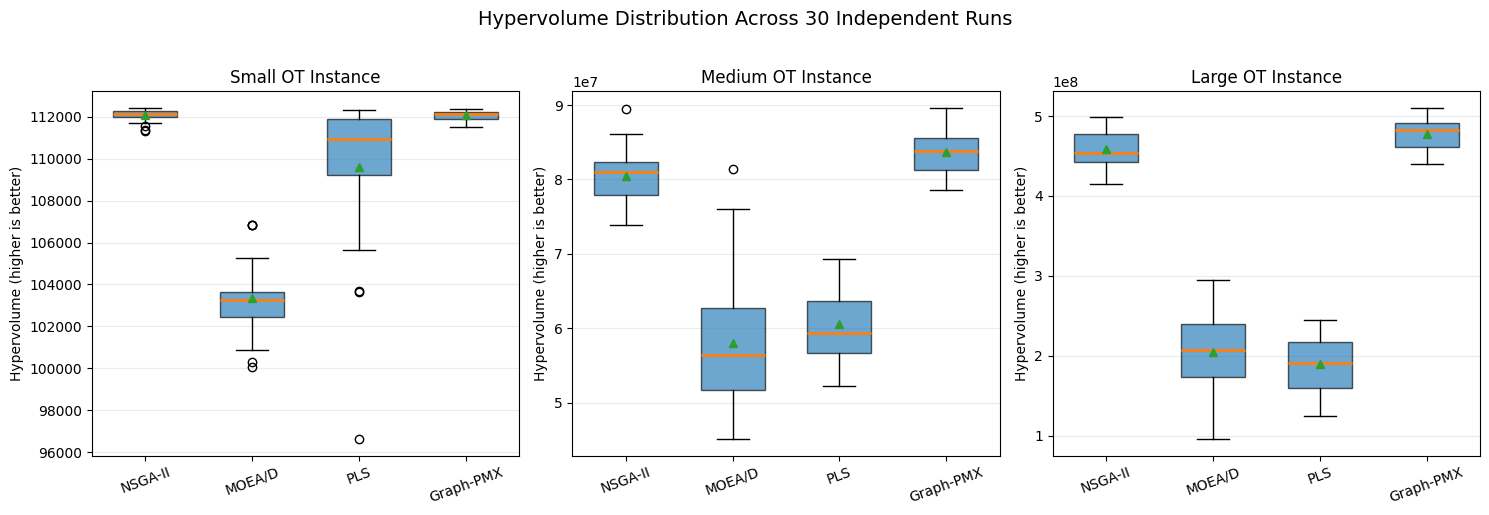

Saved: results\paper_figures\official_hv_boxplots.png
Saved: results\paper_figures\official_hv_boxplots.pdf


In [145]:
# ============================================================
# PAPER FIGURE 1
# Hypervolume distributions across 30 official-scale runs
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Combine official-scale run-level data
# ------------------------------------------------------------

plot_dfs = []

for instance_label, df in [
    ("Small",  small_official_df),
    ("Medium", medium_official_analysis["metrics"]),
    ("Large",  large_official_analysis["metrics"]),
]:
    temp = df.copy()
    temp["Instance"] = instance_label
    plot_dfs.append(temp)

official_plot_df = pd.concat(
    plot_dfs,
    ignore_index=True
)


# ------------------------------------------------------------
# 2. Algorithm order
# ------------------------------------------------------------

algorithm_order = [
    "NSGA-II",
    "MOEA/D",
    "PLS",
    "Graph-PMX NSGA-II",
]

short_labels = [
    "NSGA-II",
    "MOEA/D",
    "PLS",
    "Graph-PMX",
]


# ------------------------------------------------------------
# 3. Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)


for ax, instance in zip(
    axes,
    ["Small", "Medium", "Large"]
):

    subset = official_plot_df[
        official_plot_df["Instance"] == instance
    ]

    data = [
        subset[
            subset["algorithm"] == algorithm
        ]["hv"].to_numpy()
        for algorithm in algorithm_order
    ]


    bp = ax.boxplot(
        data,
        labels=short_labels,
        patch_artist=True,
        widths=0.6,
        showmeans=True,
    )


    # Light visual formatting
    for box in bp["boxes"]:
        box.set_alpha(0.65)

    for median in bp["medians"]:
        median.set_linewidth(2)

    ax.set_title(
        f"{instance} OT Instance",
        fontsize=12
    )

    ax.set_ylabel(
        "Hypervolume (higher is better)"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    ax.tick_params(
        axis="x",
        rotation=20
    )


# ------------------------------------------------------------
# 4. Overall title
# ------------------------------------------------------------

fig.suptitle(
    "Hypervolume Distribution Across 30 Independent Runs",
    fontsize=14,
    y=1.02
)

plt.tight_layout()


# ------------------------------------------------------------
# 5. Save publication-quality copies
# ------------------------------------------------------------

figure_dir = Path(
    "results/paper_figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True
)


plt.savefig(
    figure_dir
    / "official_hv_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    figure_dir
    / "official_hv_boxplots.pdf",
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    figure_dir
    / "official_hv_boxplots.png"
)

print(
    "Saved:",
    figure_dir
    / "official_hv_boxplots.pdf"
)


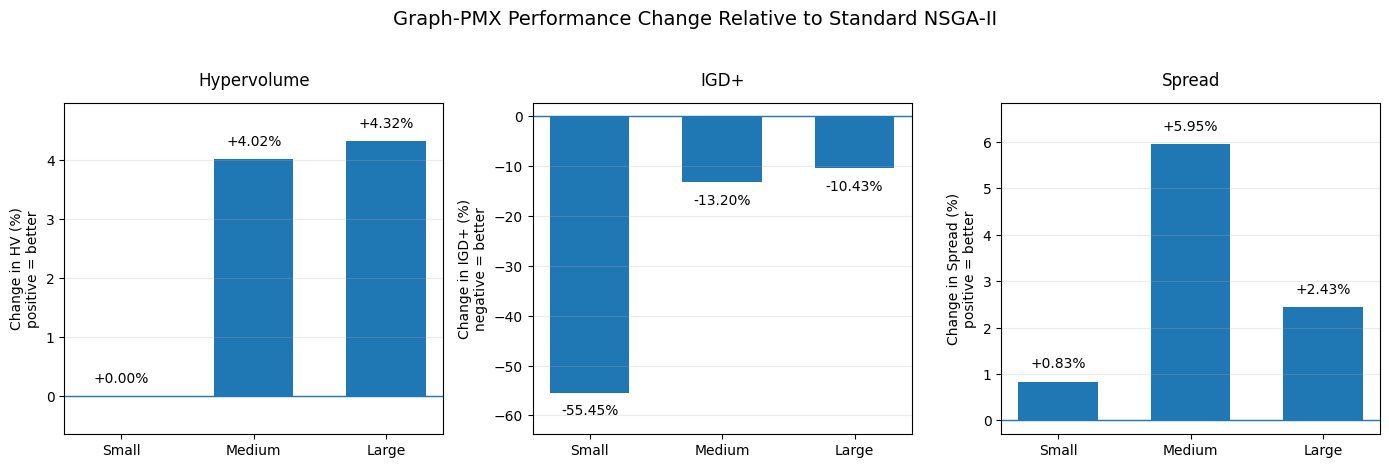

Saved: results\paper_figures\graph_pmx_relative_changes.png
Saved: results\paper_figures\graph_pmx_relative_changes.pdf


In [144]:
# ============================================================
# PAPER FIGURE 2
# Graph-PMX change relative to standard NSGA-II
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


# ------------------------------------------------------------
# 1. Extract percentage changes
# ------------------------------------------------------------

instances = ["Small", "Medium", "Large"]

hv_changes = (
    graph_change_df["HV change %"]
    .to_numpy()
)

igd_changes = (
    graph_change_df["IGD+ change %"]
    .to_numpy()
)

spread_changes = (
    graph_change_df["Spread change %"]
    .to_numpy()
)


# ------------------------------------------------------------
# 2. Plot three metrics separately
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.5)
)


metric_data = [
    (
        hv_changes,
        "Hypervolume",
        "Change in HV (%)\npositive = better"
    ),

    (
        igd_changes,
        "IGD+",
        "Change in IGD+ (%)\nnegative = better"
    ),

    (
        spread_changes,
        "Spread",
        "Change in Spread (%)\npositive = better"
    ),
]


for ax, (values, title, ylabel) in zip(
    axes,
    metric_data
):

    bars = ax.bar(
        instances,
        values,
        width=0.6
    )

    ax.axhline(
        0,
        linewidth=1
    )

    ax.set_title(
        title,
        fontsize=12,
        pad=12
    )

    ax.set_ylabel(ylabel)

    ax.grid(
        axis="y",
        alpha=0.25
    )

    # Give labels enough room above and below the bars
    value_range = max(abs(values))

    lower = min(
        min(values) - value_range * 0.15,
        -value_range * 0.05
    )

    upper = max(
        max(values) + value_range * 0.15,
        value_range * 0.05
    )

    ax.set_ylim(
        lower,
        upper
    )

    # Percentage labels
    for bar, value in zip(
        bars,
        values
    ):

        offset = value_range * 0.04

        if value >= 0:
            y = value + offset
            va = "bottom"
        else:
            y = value - offset
            va = "top"

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f"{value:+.2f}%",
            ha="center",
            va=va,
            fontsize=10
        )


# ------------------------------------------------------------
# 3. Overall title
# ------------------------------------------------------------

fig.suptitle(
    "Graph-PMX Performance Change Relative to Standard NSGA-II",
    fontsize=14,
    y=1.03
)

plt.tight_layout()


# ------------------------------------------------------------
# 4. Save
# ------------------------------------------------------------

figure_dir = Path(
    "results/paper_figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True
)


plt.savefig(
    figure_dir
    / "graph_pmx_relative_changes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    figure_dir
    / "graph_pmx_relative_changes.pdf",
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    figure_dir
    / "graph_pmx_relative_changes.png"
)

print(
    "Saved:",
    figure_dir
    / "graph_pmx_relative_changes.pdf"
)


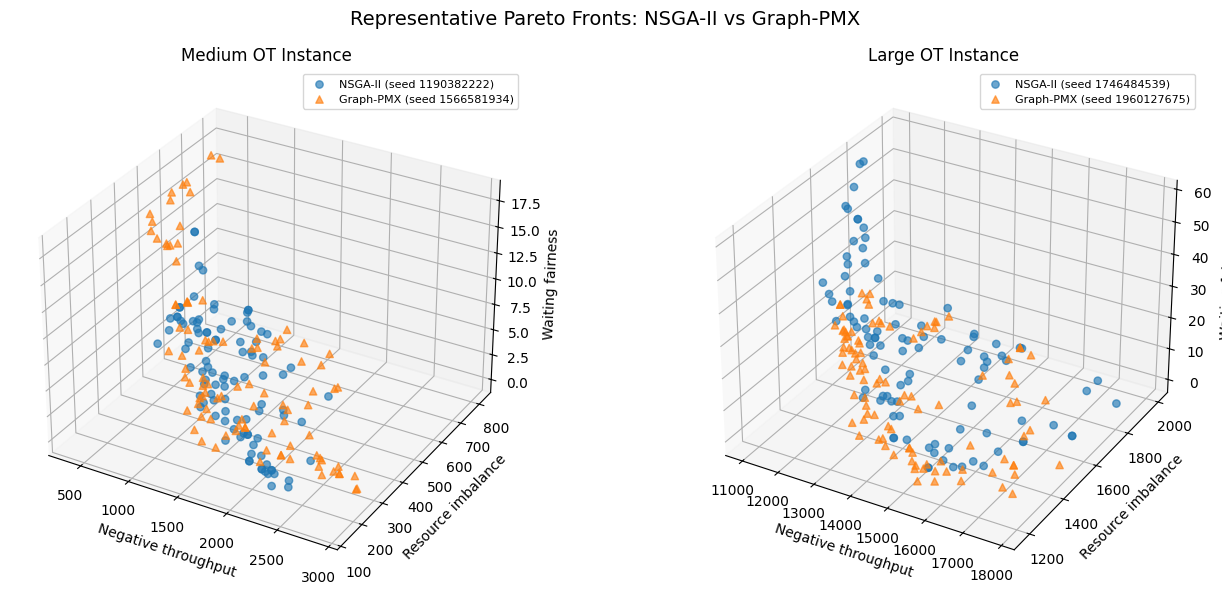

Saved: results\paper_figures\representative_pareto_fronts.png
Saved: results\paper_figures\representative_pareto_fronts.pdf


In [129]:
# ============================================================
# PAPER FIGURE 3
# Representative 3-objective Pareto fronts
# NSGA-II vs Graph-PMX
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Helper: select run closest to median HV
# ------------------------------------------------------------

def representative_front(metrics_df, runs_dict, algorithm):

    subset = (
        metrics_df[
            metrics_df["algorithm"] == algorithm
        ]
        .sort_values("seed")
        .copy()
    )

    median_hv = subset["hv"].median()

    subset["distance_from_median"] = (
        subset["hv"] - median_hv
    ).abs()

    representative = subset.loc[
        subset["distance_from_median"].idxmin()
    ]

    selected_seed = int(
        representative["seed"]
    )

    # Find corresponding stored run
    run = next(
        r for r in runs_dict[algorithm]
        if int(r["seed"]) == selected_seed
    )

    return (
        np.asarray(run["F"]),
        selected_seed,
        representative["hv"],
    )


# ------------------------------------------------------------
# 2. We'll show Medium and Large
# Small adds little because Graph-PMX ≈ NSGA-II there
# ------------------------------------------------------------

instances_for_plot = [
    (
        "Medium",
        medium_official_analysis,
    ),

    (
        "Large",
        large_official_analysis,
    ),
]


# ------------------------------------------------------------
# 3. Create 3D plots
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(14, 6)
)


for plot_index, (
    instance_label,
    analysis
) in enumerate(
    instances_for_plot,
    start=1
):

    ax = fig.add_subplot(
        1,
        2,
        plot_index,
        projection="3d"
    )


    # NSGA-II representative front
    F_nsga, seed_nsga, hv_nsga = representative_front(
    analysis["metrics"],
    analysis["runs"],
    "NSGA-II",
    )

    # Graph-PMX representative front
    F_graph, seed_graph, hv_graph = representative_front(
    analysis["metrics"],
    analysis["runs"],
    "Graph-PMX NSGA-II",
    )


    # Plot
    ax.scatter(
        F_nsga[:, 0],
        F_nsga[:, 1],
        F_nsga[:, 2],
        s=28,
        alpha=0.65,
        label=f"NSGA-II (seed {seed_nsga})",
    )


    ax.scatter(
        F_graph[:, 0],
        F_graph[:, 1],
        F_graph[:, 2],
        s=28,
        alpha=0.65,
        marker="^",
        label=f"Graph-PMX (seed {seed_graph})",
    )


    ax.set_title(
        f"{instance_label} OT Instance"
    )

    ax.set_xlabel(
    "Negative throughput"
    )

    ax.set_ylabel(
    "Resource imbalance"
    )

    ax.set_zlabel(
    "Waiting fairness "
    )

    ax.legend(
        fontsize=8
    )


# ------------------------------------------------------------
# 4. Overall title
# ------------------------------------------------------------

fig.suptitle(
    "Representative Pareto Fronts: NSGA-II vs Graph-PMX",
    fontsize=14,
    y=0.98
)

plt.tight_layout()


# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

figure_dir = Path(
    "results/paper_figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True
)


plt.savefig(
    figure_dir
    / "representative_pareto_fronts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    figure_dir
    / "representative_pareto_fronts.pdf",
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    figure_dir
    / "representative_pareto_fronts.png"
)

print(
    "Saved:",
    figure_dir
    / "representative_pareto_fronts.pdf"
)


# RECOVERED FINAL-STAGE WORK

The HTML snapshot available on disk ends before the Hidden-instance/final reproducibility stage.

The cells below reconstruct the **verified final-stage workflow** from the saved experiment folders and the recorded final analysis. They **do not rerun the 30-seed optimisation experiments**; they only reload/analyse results already saved on disk.

Keep the existing `results/final_baselines/*_hidden/` folders unchanged.

In [ ]:
hidden_official_analysis = analyse_official_baselines(
    instance_name="ot_hidden",

    nsga2_dir=
        "results/final_baselines/nsga2_hidden",

    moead_dir=
        "results/final_baselines/moead_hidden",

    pls_dir=
        "results/final_baselines/pls_hidden",

    graph_pmx_dir=
        "results/final_baselines/graph_pmx_hidden",
)

In [ ]:
official_dfs = {
    "ot_small": small_official_df,
    "ot_medium": medium_official_analysis["metrics"],
    "ot_large": large_official_analysis["metrics"],
    "ot_hidden": hidden_official_analysis["metrics"],
}

print("Instances loaded for final analysis:")
for name, df in official_dfs.items():
    print(f"{name:<12} rows={len(df)}")

In [ ]:
from pathlib import Path

print("=" * 80)
print("FINAL RESULT-FOLDER AUDIT")
print("=" * 80)

instance_map = {
    "Small": "small",
    "Medium": "medium",
    "Large": "large",
    "Hidden": "hidden",
}

algorithm_map = {
    "NSGA-II": "nsga2",
    "MOEA/D": "moead",
    "PLS": "pls",
    "Graph-PMX": "graph_pmx",
}

audit_rows = []

for instance_label, instance_key in instance_map.items():
    for algorithm_label, algorithm_key in algorithm_map.items():

        folder = Path(
            f"results/final_baselines/{algorithm_key}_{instance_key}"
        )

        run_files = sorted(folder.glob("run_*.json"))
        summary_exists = (folder / "summary.json").exists()

        audit_rows.append({
            "Instance": instance_label,
            "Algorithm": algorithm_label,
            "Run files": len(run_files),
            "Summary exists": summary_exists,
            "Complete": (
                len(run_files) == 30
                and summary_exists
            ),
        })

audit_df = pd.DataFrame(audit_rows)

print(
    audit_df.to_string(
        index=False
    )
)

print()
print(
    "All experiment folders complete:",
    bool(audit_df["Complete"].all())
)

## Standalone final analysis

The final statistics are reconstructed from the saved raw run logs by the standalone script:

```powershell
python -m scripts.analyse_final_results
```

Expected audit:

- 4 instances × 4 algorithms × 30 runs = **480 run-level rows**
- Small reference-front size = **3590**
- Medium = **642**
- Large = **701**
- Hidden = **591**
- Friedman tests are reconstructed for HV, IGD+ and spread.

This command analyses existing logs; it does **not** rerun the optimisation seeds.

## Verified final Graph-PMX exports

The saved final Graph-PMX non-dominated outputs are:

| Instance | Final ND solutions | Scheduled range | Unscheduled range |
|---|---:|---:|---:|
| Small | 66 | 18–21 | 1–4 |
| Medium | 288 | 105–114 | 6–15 |
| Large | 302 | 228–238 | 42–52 |
| Hidden | 274 | 152–158 | 42–48 |

The recorded export audit reported valid permutations and decoder-feasible schedules for all exported solutions.

Saved under:

```text
results/final_solutions/ot_small/
results/final_solutions/ot_medium/
results/final_solutions/ot_large/
results/final_solutions/ot_hidden/
```


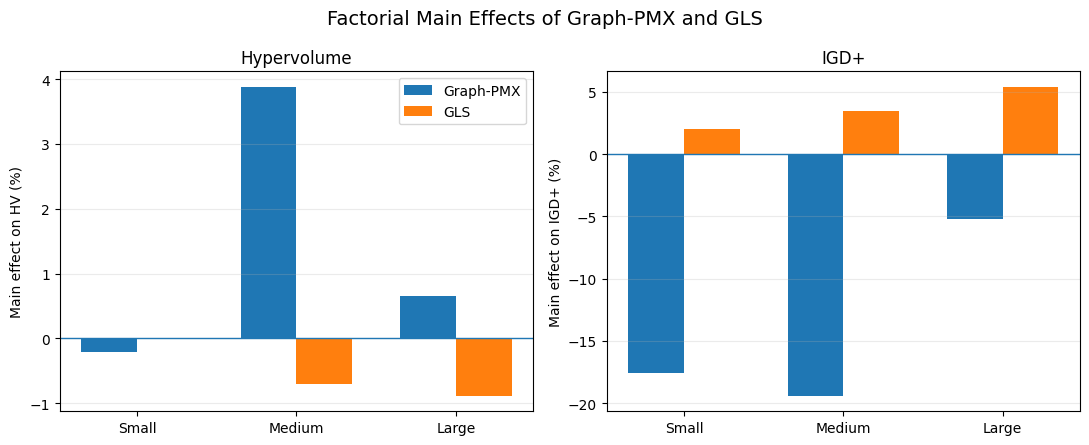

Saved: results\paper_figures\factorial_main_effects.png
Saved: results\paper_figures\factorial_main_effects.pdf


In [1]:
# ============================================================
# PAPER FIGURE 1
# Factorial main effects of Graph-PMX and GLS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


# ------------------------------------------------------------
# 1. Final factorial main-effect values reported in Table 2
# ------------------------------------------------------------

instances = [
    "Small",
    "Medium",
    "Large",
]

graph_pmx_hv = np.array([
    -0.212,
    +3.882,
    +0.659,
])

gls_hv = np.array([
    -0.011,
    -0.699,
    -0.885,
])

graph_pmx_igd = np.array([
    -17.560,
    -19.402,
    -5.211,
])

gls_igd = np.array([
    +2.025,
    +3.462,
    +5.407,
])


# ------------------------------------------------------------
# 2. Plot
# ------------------------------------------------------------

x = np.arange(
    len(instances)
)

width = 0.35

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5)
)


# ------------------------------------------------------------
# Hypervolume
# ------------------------------------------------------------

axes[0].bar(
    x - width / 2,
    graph_pmx_hv,
    width,
    label="Graph-PMX",
)

axes[0].bar(
    x + width / 2,
    gls_hv,
    width,
    label="GLS",
)

axes[0].axhline(
    0,
    linewidth=1,
)

axes[0].set_xticks(
    x
)

axes[0].set_xticklabels(
    instances
)

axes[0].set_ylabel(
    "Main effect on HV (%)"
)

axes[0].set_title(
    "Hypervolume"
)

axes[0].grid(
    axis="y",
    alpha=0.25
)

axes[0].legend()


# ------------------------------------------------------------
# IGD+
# ------------------------------------------------------------

axes[1].bar(
    x - width / 2,
    graph_pmx_igd,
    width,
    label="Graph-PMX",
)

axes[1].bar(
    x + width / 2,
    gls_igd,
    width,
    label="GLS",
)

axes[1].axhline(
    0,
    linewidth=1,
)

axes[1].set_xticks(
    x
)

axes[1].set_xticklabels(
    instances
)

axes[1].set_ylabel(
    "Main effect on IGD+ (%)"
)

axes[1].set_title(
    "IGD+"
)

axes[1].grid(
    axis="y",
    alpha=0.25
)


# ------------------------------------------------------------
# 3. Overall title
# ------------------------------------------------------------

fig.suptitle(
    "Factorial Main Effects of Graph-PMX and GLS",
    fontsize=14,
)

plt.tight_layout()


# ------------------------------------------------------------
# 4. Save
# ------------------------------------------------------------

figure_dir = Path(
    "results/paper_figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    figure_dir
    / "factorial_main_effects.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    figure_dir
    / "factorial_main_effects.pdf",
    bbox_inches="tight",
)

plt.show()


print(
    "Saved:",
    figure_dir
    / "factorial_main_effects.png"
)

print(
    "Saved:",
    figure_dir
    / "factorial_main_effects.pdf"
)

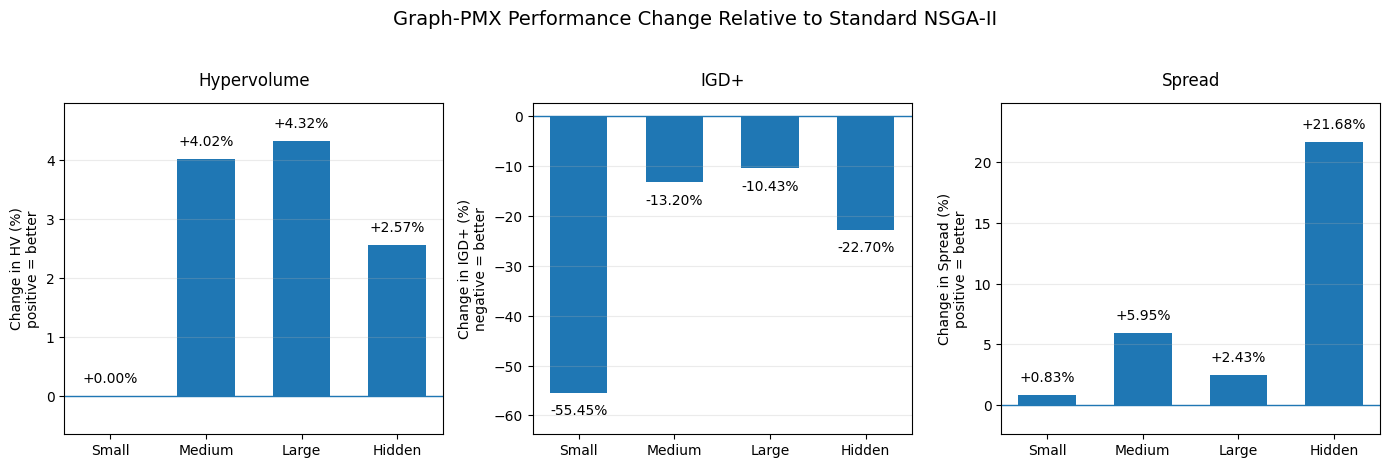

Saved: results\paper_figures\graph_pmx_relative_changes.png
Saved: results\paper_figures\graph_pmx_relative_changes.pdf


In [2]:
# ============================================================
# PAPER FIGURE 2
# Graph-PMX change relative to standard NSGA-II
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


# ------------------------------------------------------------
# 1. Final values from official-scale Table 4
# ------------------------------------------------------------

instances = [
    "Small",
    "Medium",
    "Large",
    "Hidden",
]

hv_changes = np.array([
    +0.004537,
    +4.024987,
    +4.322676,
    +2.567673,
])

igd_changes = np.array([
    -55.452719,
    -13.203725,
    -10.433981,
    -22.703849,
])

spread_changes = np.array([
    +0.829486,
    +5.947709,
    +2.431328,
    +21.681200,
])


# ------------------------------------------------------------
# 2. Plot three metrics separately
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.5),
)

metric_data = [
    (
        hv_changes,
        "Hypervolume",
        "Change in HV (%)\npositive = better",
    ),
    (
        igd_changes,
        "IGD+",
        "Change in IGD+ (%)\nnegative = better",
    ),
    (
        spread_changes,
        "Spread",
        "Change in Spread (%)\npositive = better",
    ),
]


for ax, (
    values,
    title,
    ylabel,
) in zip(
    axes,
    metric_data,
):

    bars = ax.bar(
        instances,
        values,
        width=0.6,
    )

    ax.axhline(
        0,
        linewidth=1,
    )

    ax.set_title(
        title,
        fontsize=12,
        pad=12,
    )

    ax.set_ylabel(
        ylabel
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )

    value_range = max(
        abs(values)
    )

    lower = min(
        min(values)
        - value_range * 0.15,
        -value_range * 0.05,
    )

    upper = max(
        max(values)
        + value_range * 0.15,
        value_range * 0.05,
    )

    ax.set_ylim(
        lower,
        upper,
    )

    # Percentage labels
    for bar, value in zip(
        bars,
        values,
    ):

        offset = (
            value_range
            * 0.04
        )

        if value >= 0:
            y = value + offset
            va = "bottom"

        else:
            y = value - offset
            va = "top"

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            y,
            f"{value:+.2f}%",
            ha="center",
            va=va,
            fontsize=10,
        )


# ------------------------------------------------------------
# 3. Overall title
# ------------------------------------------------------------

fig.suptitle(
    "Graph-PMX Performance Change Relative to Standard NSGA-II",
    fontsize=14,
    y=1.03,
)

plt.tight_layout()


# ------------------------------------------------------------
# 4. Save
# ------------------------------------------------------------

figure_dir = Path(
    "results/paper_figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    figure_dir
    / "graph_pmx_relative_changes.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    figure_dir
    / "graph_pmx_relative_changes.pdf",
    bbox_inches="tight",
)

plt.show()


print(
    "Saved:",
    figure_dir
    / "graph_pmx_relative_changes.png"
)

print(
    "Saved:",
    figure_dir
    / "graph_pmx_relative_changes.pdf"
)

C:\Users\masri\AppData\Local\Temp\ipykernel_48552\3033370396.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\masri\AppData\Local\Temp\ipykernel_48552\3033370396.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\masri\AppData\Local\Temp\ipykernel_48552\3033370396.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\masri\AppData\Local\Temp\ipykernel_48552\3033370396.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped 

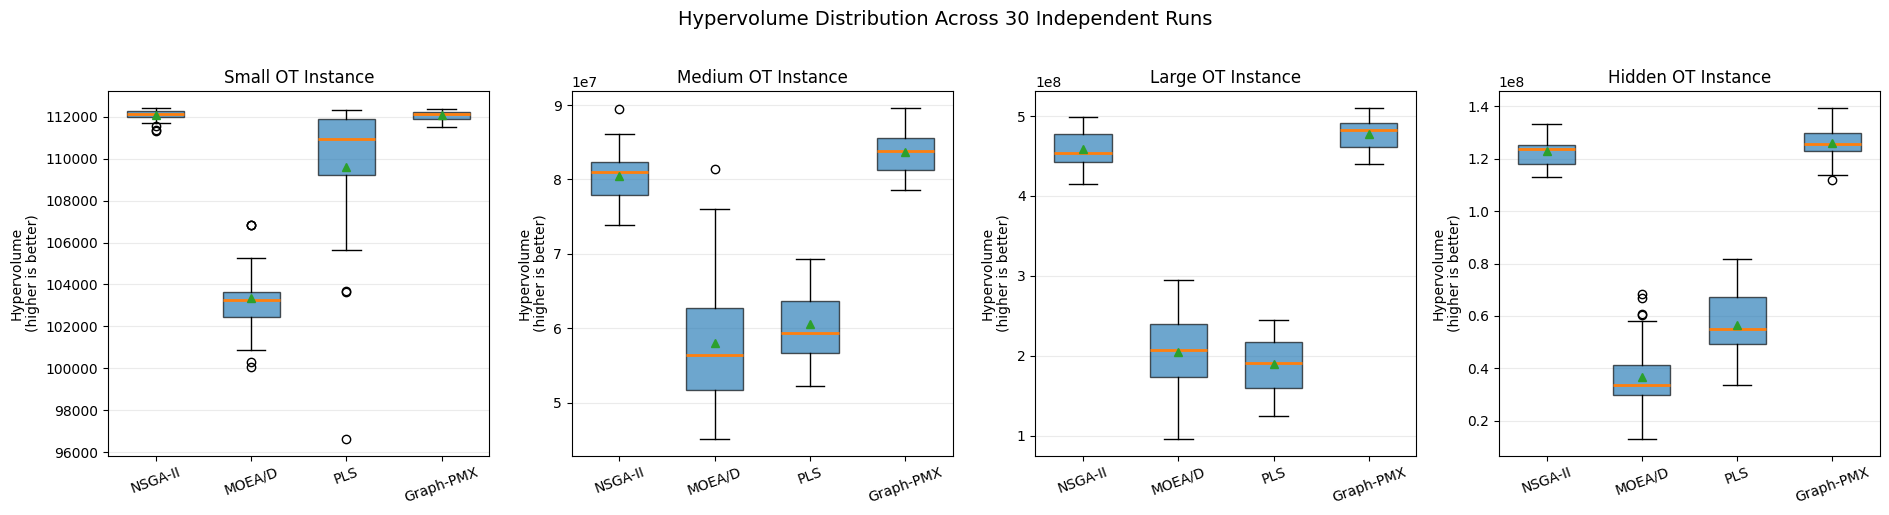

In [3]:
# ============================================================
# OPTIONAL PAPER FIGURE
# Hypervolume distributions across 30 official-scale runs
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# 1. Load final reconstructed run-level metrics
# ------------------------------------------------------------

metrics_path = Path(
    "results/reproducibility_analysis/all_run_metrics.csv"
)

official_plot_df = pd.read_csv(
    metrics_path
)


# ------------------------------------------------------------
# 2. Standardise instance labels
# ------------------------------------------------------------

instance_map = {
    "Small": "Small",
    "Medium": "Medium",
    "Large": "Large",
    "Hidden": "Hidden",
    "ot_small": "Small",
    "ot_medium": "Medium",
    "ot_large": "Large",
    "ot_hidden": "Hidden",
}

official_plot_df[
    "Instance"
] = official_plot_df[
    "instance"
].map(instance_map)


# ------------------------------------------------------------
# 3. Algorithm order
# ------------------------------------------------------------

algorithm_order = [
    "NSGA-II",
    "MOEA/D",
    "PLS",
    "Graph-PMX NSGA-II",
]

short_labels = [
    "NSGA-II",
    "MOEA/D",
    "PLS",
    "Graph-PMX",
]


# ------------------------------------------------------------
# 4. Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    4,
    figsize=(19, 5),
)

for ax, instance in zip(
    axes,
    [
        "Small",
        "Medium",
        "Large",
        "Hidden",
    ],
):

    subset = official_plot_df[
        official_plot_df[
            "Instance"
        ]
        == instance
    ]

    data = [
        subset[
            subset[
                "algorithm"
            ]
            == algorithm
        ]["hv"].to_numpy()

        for algorithm
        in algorithm_order
    ]

    bp = ax.boxplot(
        data,
        labels=short_labels,
        patch_artist=True,
        widths=0.6,
        showmeans=True,
    )

    for box in bp["boxes"]:
        box.set_alpha(
            0.65
        )

    for median in bp[
        "medians"
    ]:
        median.set_linewidth(
            2
        )

    ax.set_title(
        f"{instance} OT Instance",
        fontsize=12,
    )

    ax.set_ylabel(
        "Hypervolume\n(higher is better)"
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )

    ax.tick_params(
        axis="x",
        rotation=20,
    )


fig.suptitle(
    "Hypervolume Distribution Across 30 Independent Runs",
    fontsize=14,
    y=1.02,
)

plt.tight_layout()


# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

figure_dir = Path(
    "results/paper_figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    figure_dir
    / "official_hv_boxplots_all_instances.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    figure_dir
    / "official_hv_boxplots_all_instances.pdf",
    bbox_inches="tight",
)

plt.show()

Loaded metrics: 480
results\final_baselines\nsga2_medium: loaded 30 runs
results\final_baselines\graph_pmx_medium: loaded 30 runs
results\final_baselines\nsga2_large: loaded 30 runs
results\final_baselines\graph_pmx_large: loaded 30 runs


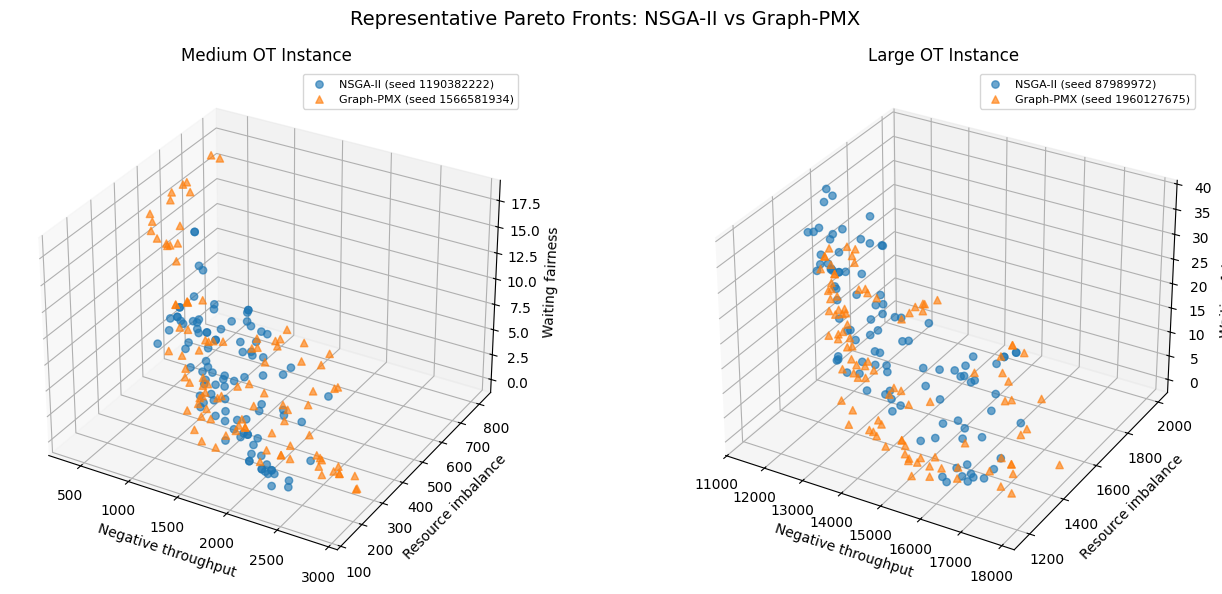


Medium representative seeds: 1190382222 1566581934
Large representative seeds: 87989972 1960127675

Saved: results\paper_figures\representative_pareto_fronts.png


In [5]:
# ============================================================
# REPRESENTATIVE 3-OBJECTIVE PARETO FRONTS
# NSGA-II vs Graph-PMX
# Loads existing saved runs directly from disk
# ============================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Helper: load all saved JSON runs
# ------------------------------------------------------------

def load_saved_runs(folder):

    folder = Path(folder)

    run_files = sorted(
        folder.glob("run_*.json")
    )

    runs = []

    for file in run_files:

        with open(file, "r") as f:
            run = json.load(f)

        runs.append(run)

    print(
        f"{folder}: loaded {len(runs)} runs"
    )

    return runs


# ------------------------------------------------------------
# 2. Helper: find run-level HV from reconstructed metrics
# ------------------------------------------------------------

metrics_path = Path(
    "results/reproducibility_analysis/all_run_metrics.csv"
)

metrics_df = pd.read_csv(
    metrics_path
)

print(
    "Loaded metrics:",
    len(metrics_df)
)


# ------------------------------------------------------------
# 3. Normalise instance names
# ------------------------------------------------------------

def instance_mask(df, instance_name):

    possible_names = {
        instance_name,
        instance_name.lower(),
        f"ot_{instance_name.lower()}",
        instance_name.capitalize(),
    }

    return (
        df["instance"]
        .astype(str)
        .isin(possible_names)
    )


# ------------------------------------------------------------
# 4. Select representative run closest to median HV
# ------------------------------------------------------------

def representative_front(
    instance_name,
    algorithm,
    runs,
):

    subset = metrics_df[
        instance_mask(
            metrics_df,
            instance_name,
        )
        &
        (
            metrics_df["algorithm"]
            == algorithm
        )
    ].copy()

    if subset.empty:

        raise ValueError(
            f"No metrics found for "
            f"{instance_name} / {algorithm}"
        )

    median_hv = subset[
        "hv"
    ].median()

    subset[
        "distance_from_median"
    ] = (
        subset["hv"]
        - median_hv
    ).abs()

    representative = subset.loc[
        subset[
            "distance_from_median"
        ].idxmin()
    ]

    selected_seed = int(
        representative["seed"]
    )

    matching_runs = [
        r for r in runs
        if int(r["seed"])
        == selected_seed
    ]

    if not matching_runs:

        raise ValueError(
            f"Seed {selected_seed} "
            f"not found in saved runs."
        )

    run = matching_runs[0]

    F = np.asarray(
        run["F"],
        dtype=float,
    )

    return (
        F,
        selected_seed,
        float(
            representative["hv"]
        ),
    )


# ------------------------------------------------------------
# 5. Load existing Medium and Large runs
# ------------------------------------------------------------

medium_nsga_runs = load_saved_runs(
    "results/final_baselines/nsga2_medium"
)

medium_graph_runs = load_saved_runs(
    "results/final_baselines/graph_pmx_medium"
)

large_nsga_runs = load_saved_runs(
    "results/final_baselines/nsga2_large"
)

large_graph_runs = load_saved_runs(
    "results/final_baselines/graph_pmx_large"
)


# ------------------------------------------------------------
# 6. Get representative fronts
# ------------------------------------------------------------

F_medium_nsga, seed_medium_nsga, hv_medium_nsga = (
    representative_front(
        "Medium",
        "NSGA-II",
        medium_nsga_runs,
    )
)

F_medium_graph, seed_medium_graph, hv_medium_graph = (
    representative_front(
        "Medium",
        "Graph-PMX NSGA-II",
        medium_graph_runs,
    )
)

F_large_nsga, seed_large_nsga, hv_large_nsga = (
    representative_front(
        "Large",
        "NSGA-II",
        large_nsga_runs,
    )
)

F_large_graph, seed_large_graph, hv_large_graph = (
    representative_front(
        "Large",
        "Graph-PMX NSGA-II",
        large_graph_runs,
    )
)


# ------------------------------------------------------------
# 7. Plot
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(14, 6)
)


# MEDIUM
ax1 = fig.add_subplot(
    1,
    2,
    1,
    projection="3d",
)

ax1.scatter(
    F_medium_nsga[:, 0],
    F_medium_nsga[:, 1],
    F_medium_nsga[:, 2],
    s=28,
    alpha=0.65,
    label=(
        f"NSGA-II "
        f"(seed {seed_medium_nsga})"
    ),
)

ax1.scatter(
    F_medium_graph[:, 0],
    F_medium_graph[:, 1],
    F_medium_graph[:, 2],
    s=28,
    alpha=0.65,
    marker="^",
    label=(
        f"Graph-PMX "
        f"(seed {seed_medium_graph})"
    ),
)

ax1.set_title(
    "Medium OT Instance"
)

ax1.set_xlabel(
    "Negative throughput"
)

ax1.set_ylabel(
    "Resource imbalance"
)

ax1.set_zlabel(
    "Waiting fairness"
)

ax1.legend(
    fontsize=8
)


# LARGE
ax2 = fig.add_subplot(
    1,
    2,
    2,
    projection="3d",
)

ax2.scatter(
    F_large_nsga[:, 0],
    F_large_nsga[:, 1],
    F_large_nsga[:, 2],
    s=28,
    alpha=0.65,
    label=(
        f"NSGA-II "
        f"(seed {seed_large_nsga})"
    ),
)

ax2.scatter(
    F_large_graph[:, 0],
    F_large_graph[:, 1],
    F_large_graph[:, 2],
    s=28,
    alpha=0.65,
    marker="^",
    label=(
        f"Graph-PMX "
        f"(seed {seed_large_graph})"
    ),
)

ax2.set_title(
    "Large OT Instance"
)

ax2.set_xlabel(
    "Negative throughput"
)

ax2.set_ylabel(
    "Resource imbalance"
)

ax2.set_zlabel(
    "Waiting fairness"
)

ax2.legend(
    fontsize=8
)


# ------------------------------------------------------------
# 8. Overall title
# ------------------------------------------------------------

fig.suptitle(
    "Representative Pareto Fronts: NSGA-II vs Graph-PMX",
    fontsize=14,
    y=0.98,
)

plt.tight_layout()


# ------------------------------------------------------------
# 9. Save
# ------------------------------------------------------------

figure_dir = Path(
    "results/paper_figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    figure_dir
    / "representative_pareto_fronts.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    figure_dir
    / "representative_pareto_fronts.pdf",
    bbox_inches="tight",
)

plt.show()


print()
print(
    "Medium representative seeds:",
    seed_medium_nsga,
    seed_medium_graph,
)

print(
    "Large representative seeds:",
    seed_large_nsga,
    seed_large_graph,
)

print()
print(
    "Saved:",
    figure_dir
    / "representative_pareto_fronts.png"
)